# Synthetic CDO — End-to-End Valuation & Risk Pipeline

**Document type:** Model working paper (Quant / Risk desk)
**Audience:** Structured Credit desk, Model Validation, Risk Management
**References:** Mounfield (2009) *Synthetic CDOs: Modelling, Valuation & Risk Management* · Hull (2018) Ch.25 · JP Morgan (2004) *Base Correlation* · ISDA 2003 CDS Standard

---

### 1. Executive summary

Notebook này triển khai một **pricing & risk pipeline chuẩn sell-side** cho synthetic CDO tranche trên reference portfolio gồm các CDS 5Y quote được lấy từ `cds.csv` (ngày định giá = snapshot mới nhất). Pipeline được thiết kế theo luồng **term-sheet → market data → marginal credit curves → dependence model → tranche cash flows → calibration → sensitivities → stress → dashboard**, phù hợp với quy trình của một dealer hoặc một risk officer khi đánh giá clean price, hedge và capital charge của deal.

**Thành phần mô hình:**

| Khối | Phương pháp | Tham chiếu |
|---|---|---|
| Marginal default curves | ISDA-consistent piecewise-constant hazard bootstrap | Mounfield Ch.3 |
| Dependence | One-factor Gaussian copula (Vasicek 1987 / Li 2000) | Mounfield Ch.6 |
| Pricing engine | Monte Carlo default-time sampling + antithetic variates | Mounfield Ch.7 |
| Semi-analytic benchmark | LHP (Large Homogeneous Pool) Vasicek closed-form | Mounfield §6.5 |
| Calibration | Base correlation curve (bisection on ETL) | JP Morgan 2004 |
| Sensitivities | CS01, Rho01, DV01, JtD (per-tranche + per-name) | Mounfield Ch.8 |
| Stress | Shock grid (spread, recovery, correlation, combined crisis) | Mounfield Ch.7 |

**Cấu trúc notebook:**

- **Part I** — Framework & market setup
- **Part II** — Credit curves (hazard bootstrapping)
- **Part III** — One-factor Gaussian copula
- **Part IV** — Tranche pricing (MC engine)
- **Part V** — Calibration via base correlation
- **Part VI** — Risk analytics (Greeks, stress)
- **Part VII** — Portfolio insight & dashboard


## Part I — Framework & market setup

Pipeline bắt đầu bằng việc cố định **term sheet của deal** và thu thập **market inputs tối thiểu**: discount curve, CDS spreads theo tenor chuẩn, và giả định recovery. Với synthetic CDO tiêu chuẩn (iTraxx/CDX-like), term sheet gồm:

- Reference portfolio $\{i=1,\dots,N\}$ với notional $N_i$ và CDS quotes.
- Lịch coupon (quarterly, act/360 thông thường) và maturity $T$.
- Capital structure: các cặp attachment/detachment $[A_j, D_j]$ (equity, mezz, junior senior, senior…).
- Running premium (quoted in bps/năm) và/hoặc upfront (với equity).

Ngày định giá là snapshot cuối của cds.csv.


### §1.1 Environment & style

Module phụ thuộc: `numpy`, `pandas`, `matplotlib`, `seaborn`. Không phụ thuộc `scipy` để pipeline portable — các hàm thống kê chuẩn (CDF, PPF) được implement nội bộ qua `_NormDist` dựa trên `math.erf` + Acklam PPF. RNG mặc định seed = 42 để kết quả tái lập (reproducibility chuẩn validation).


In [1]:
# ── §1.1 Environment ──────────────────────────────────────────
# Pipeline deps: numpy / pandas / matplotlib / seaborn.
# Implement N(0,1) CDF & PPF in-house (Acklam 2003) để notebook chạy
# không cần scipy — tiện cho validation portability.

import math as _math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _erf_v(x):
    xa = np.asarray(x, dtype=float)
    return np.vectorize(_math.erf)(xa)

class _NormDist:
    """Standard-normal CDF/PPF — CDF via math.erf, PPF via Acklam approx."""
    _SQRT2 = _math.sqrt(2.0)
    def cdf(self, x):
        return 0.5 * (1.0 + _erf_v(np.asarray(x, float) / self._SQRT2))
    def ppf(self, p):
        p = np.asarray(p, dtype=float)
        scalar = p.ndim == 0
        p = np.atleast_1d(p)
        out = np.empty_like(p)
        a = (-3.969683028665376e+01,  2.209460984245205e+02,
             -2.759285104469687e+02,  1.383577518672690e+02,
             -3.066479806614716e+01,  2.506628277459239e+00)
        b = (-5.447609879822406e+01,  1.615858368580409e+02,
             -1.556989798598866e+02,  6.680131188771972e+01,
             -1.328068155288572e+01)
        c = (-7.784894002430293e-03, -3.223964580411365e-01,
             -2.400758277161838e+00, -2.549732539343734e+00,
              4.374664141464968e+00,  2.938163982698783e+00)
        d = ( 7.784695709041462e-03,  3.224671290700398e-01,
              2.445134137142996e+00,  3.754408661907416e+00)
        p_lo, p_hi = 0.02425, 1 - 0.02425
        for i, pi in enumerate(p.flat):
            pi = float(pi)
            if pi <= 0:   out.flat[i] = -_math.inf; continue
            if pi >= 1:   out.flat[i] =  _math.inf; continue
            if pi < p_lo:
                q = _math.sqrt(-2*_math.log(pi))
                x = (((((c[0]*q+c[1])*q+c[2])*q+c[3])*q+c[4])*q+c[5]) / ((((d[0]*q+d[1])*q+d[2])*q+d[3])*q+1)
            elif pi <= p_hi:
                q = pi - 0.5; r = q*q
                x = (((((a[0]*r+a[1])*r+a[2])*r+a[3])*r+a[4])*r+a[5])*q / (((((b[0]*r+b[1])*r+b[2])*r+b[3])*r+b[4])*r+1)
            else:
                q = _math.sqrt(-2*_math.log(1-pi))
                x = -(((((c[0]*q+c[1])*q+c[2])*q+c[3])*q+c[4])*q+c[5]) / ((((d[0]*q+d[1])*q+d[2])*q+d[3])*q+1)
            # one Halley refinement
            e = 0.5 * _math.erfc(-x/_math.sqrt(2)) - pi
            x -= e * _math.sqrt(2*_math.pi) * _math.exp(0.5*x*x)
            out.flat[i] = x
        return float(out[0]) if scalar else out

norm = _NormDist()

# Plot style — institutional monochrome with two accent colours
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "font.family": "sans-serif",
})
ACCENT, SECONDARY = "#1f4e79", "#c55a11"
TRANCHE_COLORS = {"Equity":"#c62828", "Mezz":"#e67e22",
                  "Junior sen.":"#2e7d32", "Senior":"#1565c0"}

# Global RNG for reproducibility
RNG = np.random.default_rng(42)

print("Environment ready — numpy", np.__version__, "| pandas", pd.__version__)


Environment ready — numpy 1.26.4 | pandas 2.2.2


### §1.2 Term sheet — standard tranche structure

Sử dụng capital structure tiêu chuẩn kiểu **iTraxx Europe Main** được compact hoá cho minh hoạ:

| Tranche | Attach A | Detach D | Width | Rủi ro kinh tế |
|---|---|---|---|---|
| Equity | 0% | 3% | 3% | Nhận lỗ đầu tiên, long correlation |
| Mezzanine | 3% | 7% | 4% | Short gamma, nhạy default clustering |
| Junior Senior | 7% | 10% | 3% | Bảo vệ kép, rho-neutral |
| Senior | 10% | 15% | 5% | Tail protection, short correlation |

Công thức tổn thất tranche chuẩn:
$$L^{[A,D]}(t) \;=\; \min\!\bigl( \max(L^{\text{pool}}(t)-A,0),\; D-A \bigr).$$


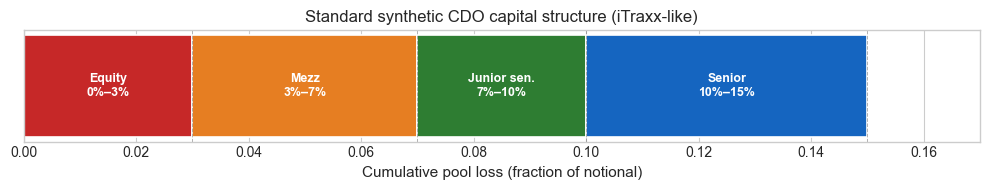

    Tranche  Attach  Detach  Width
     Equity    0.00    0.03   0.03
       Mezz    0.03    0.07   0.04
Junior sen.    0.07    0.10   0.03
     Senior    0.10    0.15   0.05


In [2]:
# ── §1.2 Term sheet — standard tranche structure ─────────────
TRANCHES = [
    ("Equity",      0.00, 0.03),
    ("Mezz",        0.03, 0.07),
    ("Junior sen.", 0.07, 0.10),
    ("Senior",      0.10, 0.15),
]
attach  = np.array([a for _, a, _ in TRANCHES])
detach  = np.array([d for _, _, d in TRANCHES])
widths  = detach - attach

# Visual capital-structure ladder
fig, ax = plt.subplots(figsize=(10, 2.0))
cols = [TRANCHE_COLORS[n] for n, *_ in TRANCHES]
ax.barh(0, widths, left=attach, height=0.35, color=cols,
        edgecolor="white", linewidth=1.2)
for name, a, d in TRANCHES:
    ax.text((a+d)/2, 0, f"{name}\n{a:.0%}–{d:.0%}",
            ha="center", va="center", fontsize=9, color="white",
            fontweight="bold")
for x in [0.03, 0.07, 0.10, 0.15]:
    ax.axvline(x, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_yticks([]); ax.set_xlim(0, 0.17)
ax.set_xlabel("Cumulative pool loss (fraction of notional)")
ax.set_title("Standard synthetic CDO capital structure (iTraxx-like)")
plt.tight_layout(); plt.show()

print(pd.DataFrame(TRANCHES, columns=["Tranche","Attach","Detach"])
      .assign(Width=lambda df: df["Detach"]-df["Attach"])
      .to_string(index=False))


### §1.3 Market data — CDS time-series & reference pool

File `cds.csv` chứa CDS single-name tại nhiều tenor $\{1,2,3,5,7,10\}$Y cho một rổ hàng trăm issuer Bắc Mỹ/Châu Âu. Chúng ta pivot sang wide-format (Date × Ticker × Tenor) và chuyển spread từ basis-point sang **decimal** (chia 10 000). Reference pool bắt đầu từ cột `PX5_*` (5Y spread) vì maturity deal được đặt mặc định $T=5$Y — phù hợp standard iTraxx.


In [3]:
# ── §1.3 Market data — CDS time series ───────────────────────
cds_df = pd.read_csv("cds.csv")
cds_df["Date"] = pd.to_datetime(cds_df["Date"])
cds_df = cds_df.set_index("Date")

# Wide-format: columns = PX{tenor}_{ticker}, values = decimal (bp/10 000)
cds_df1 = cds_df.pivot_table(index="Date", columns="Ticker",
                             values=[f"PX{i}" for i in range(1, 11)]) / 1e4
cds_df1.columns = [f"{px}_{tic}" for px, tic in cds_df1.columns]

# 5Y pool — will be used as reference pool for tranche pricing
PX_TENOR = 5
pool_cols = sorted(c for c in cds_df1.columns if c.startswith(f"PX{PX_TENOR}_"))
pool_cds  = cds_df1[pool_cols]

print(f"CDS frame          : {cds_df1.shape[0]} dates × {cds_df1.shape[1]} (tenor,ticker) columns")
print(f"5Y reference pool  : {len(pool_cols)} issuers")
print(f"Latest snapshot    : {pool_cds.index[-1].date()}")


CDS frame          : 1747 dates × 6610 (tenor,ticker) columns
5Y reference pool  : 661 issuers
Latest snapshot    : 2021-09-10


### §1.4 Discount curve & recovery assumption

Chúng ta dùng **flat continuous risk-free rate** $r=2\%$ (có thể swap bằng OIS/SOFR curve thực tế):
$$DF(t) = e^{-rt}.$$

Recovery được fix $R=40\%$ (ISDA convention cho senior unsecured) ⇒ **LGD** $=1-R=60\%$. Trong Part VI ta sẽ shock recovery về 25% và 10% để đánh giá stress distressed recovery.


In [4]:
# ── §1.4 Discount curve & recovery ───────────────────────────
risk_free_rate = 0.02
def discount_factor(t):
    return float(np.exp(-risk_free_rate * t))

R   = 0.40               # ISDA convention (senior unsecured)
LGD = 1.0 - R

print(f"Risk-free rate r = {risk_free_rate:.1%}   (flat continuous)")
print(f"Recovery rate  R = {R:.0%}   |  LGD = {LGD:.0%}")


Risk-free rate r = 2.0%   (flat continuous)
Recovery rate  R = 40%   |  LGD = 60%


## Part II — Credit curves (marginal default probabilities)

Mỗi reference entity $i$ cần một **survival curve** $Q_i(t)$ — cung cấp xác suất không vỡ nợ đến thời điểm $t$ dưới độ đo risk-neutral $\mathbb Q$. Từ đây suy ra PD theo kỳ hạn: $p_i(T)=1-Q_i(T)$.

Có hai cách build:

1. **Flat-hazard shortcut** (Part II.1): $\lambda_i = s^{5\mathrm Y}_i / (1-R)$. Nhanh, nhưng *bỏ qua term structure*.
2. **Piecewise-constant bootstrap** (Part II.2): với mỗi quote $s^{T_k}_i$, tìm $\lambda_i^{(k)}$ sao cho NPV của CDS hợp đồng đúng bằng 0 dưới độ đo risk-neutral → ISDA-consistent.


### §2.1 Flat-hazard approximation (pedagogical baseline)

Áp dụng công thức credit-triangle Hull:
$$\lambda_i \approx \frac{s_i}{1-R}.$$

Công thức này đúng trong giới hạn coupon frequency → ∞ và risk-free rate = 0. Ta dùng nó làm **baseline** để so sánh với bootstrap ISDA chuẩn trong §2.2–§2.3.


In [5]:
# ── §2.1 Flat-hazard baseline ────────────────────────────────
# λ_i ≈ s_i / (1-R)  — Hull credit-triangle shortcut.
hazard_rate_df = pool_cds.astype(float) / (1 - R)

hazard_last = hazard_rate_df.iloc[-1].astype(float)
valid       = hazard_last.notna() & (hazard_last.values > 0)
hazard_vec  = hazard_last.loc[valid].values.astype(np.float64)

valuation_date = hazard_rate_df.index[-1]
N              = len(hazard_vec)
weights        = np.full(N, 1.0 / N)

print(f"Valuation date       : {valuation_date.date()}")
print(f"Pool size N          : {N} names (equal-weighted)")
print(f"Flat 5Y PD (pool avg): {(1 - np.exp(-hazard_vec*5)).mean()*100:.3f}%")
print(f"Flat 5Y PD range     : "
      f"[{(1 - np.exp(-hazard_vec*5)).min()*100:.3f}%, "
      f"{(1 - np.exp(-hazard_vec*5)).max()*100:.3f}%]")


Valuation date       : 2021-09-10
Pool size N          : 651 names (equal-weighted)
Flat 5Y PD (pool avg): 5.574%
Flat 5Y PD range     : [0.859%, 47.778%]


### §2.2 ISDA piecewise-constant hazard bootstrap

Giả sử $\lambda_i(t)$ là hàm piecewise-constant trên các breakpoints $0=T_0<T_1<\dots<T_K$ tương ứng tenor $\{1,2,3,5,7,10\}$Y. Khi đó:
$$Q_i(t) = \exp\!\Bigl(-\sum_k \lambda_i^{(k)} \,\Delta_k(t)\Bigr), \quad \Delta_k(t)=\max\!\bigl(\min(T_k,t)-T_{k-1},0\bigr).$$

Cho mỗi tenor $T_k$ ta giải bisection để NPV CDS bằng 0:
$$
\underbrace{\int_0^{T_k} s\,DF(u)\,Q(u)\,du}_{\text{premium leg (annuity)}} \;=\; \underbrace{(1-R)\!\int_0^{T_k} DF(u)\bigl(-dQ(u)\bigr)}_{\text{protection leg}}.
$$

Quá trình lặp qua $k=1\dots K$, mỗi lần fix $\lambda^{(1)},\dots,\lambda^{(k-1)}$ và giải cho $\lambda^{(k)}$ — đây chính là cách ISDA Standard Model được triển khai.


In [6]:
# ── §2.2 Piecewise-constant hazard bootstrap (ISDA) ──────────
BOOT_TENORS = np.array([1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
BOOT_FREQ   = 4          # quarterly coupon
R_BOOT      = R
r_BOOT      = risk_free_rate

def Q_pwc(t, lams, bps):
    """Survival probability under piecewise-constant hazards."""
    q, t0 = 1.0, 0.0
    for j, T_j in enumerate(bps):
        seg = min(T_j, t) - t0
        if seg <= 0: continue
        q *= np.exp(-lams[j] * seg)
        t0 = T_j
        if t <= T_j: break
    else:
        if t > bps[-1]:
            q *= np.exp(-lams[-1] * (t - bps[-1]))
    return q

def _cds_npv_piece(lam_new, lams_prev, bps_prev, T, s,
                   R=R_BOOT, r=r_BOOT, freq=BOOT_FREQ):
    """NPV = protection leg – premium leg for CDS maturing at T."""
    lams = list(lams_prev) + [lam_new]
    bps  = list(bps_prev)  + [T]
    dt   = 1.0 / freq
    times = np.arange(dt, T + dt*0.5, dt)
    fee, prot, Q_prev, t_prev = 0.0, 0.0, 1.0, 0.0
    for tk in times:
        tk   = min(tk, T)
        Qk   = Q_pwc(tk, lams, bps)
        df   = np.exp(-r*tk)
        dt_k = tk - t_prev
        fee  += s * dt_k * df * 0.5 * (Q_prev + Qk)
        prot += (1-R) * df * (Q_prev - Qk)
        Q_prev, t_prev = Qk, tk
    return prot - fee

def bootstrap_single(spreads_bps, tenors=BOOT_TENORS):
    """Bisection bootstrap of λ_k for each tenor, forward-propagating."""
    lams, bps = [], []
    for T, s_bps in zip(tenors, spreads_bps):
        if np.isnan(s_bps) or s_bps <= 0:
            lams.append(lams[-1] if lams else 1e-5)
        else:
            s = s_bps / 1e4
            lo, hi = 1e-8, 5.0
            for _ in range(80):
                mid = 0.5*(lo + hi)
                if _cds_npv_piece(mid, lams, bps, T, s) > 0: hi = mid
                else:                                        lo = mid
            lams.append(0.5*(lo + hi))
        bps.append(T)
    return np.array(lams), np.array(bps)

print("ISDA bootstrap ready   —  breakpoints", BOOT_TENORS.tolist())


ISDA bootstrap ready   —  breakpoints [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]


In [7]:
# ── §2.2b Run bootstrap on full pool ─────────────────────────
import time as _time

cds_raw   = pd.read_csv("cds.csv")
cds_raw["Date"] = pd.to_datetime(cds_raw["Date"])
snap      = cds_raw[cds_raw["Date"] == cds_raw["Date"].max()].copy().set_index("Ticker")
BOOT_COL  = {t: f"PX{int(t)}" for t in [1,2,3,5,7,10]}

pool_boot = []
t0 = _time.time()
for ticker, row in snap.iterrows():
    sp = [row.get(BOOT_COL[t], np.nan) for t in [1,2,3,5,7,10]]
    if all(np.isnan(s) for s in sp): continue
    lams, bps = bootstrap_single(sp)
    pool_boot.append((ticker, lams, bps))

N_boot          = len(pool_boot)
pD_5Y_boot_full = np.array([1 - Q_pwc(5.0, l, b) for _, l, b in pool_boot])
pD_flat_5Y      = 1 - np.exp(-hazard_vec * 5.0)

print(f"Bootstrapped {N_boot} names in {_time.time()-t0:.1f}s")
print(f"5Y PD (flat)       : mean {pD_flat_5Y.mean()*100:6.3f}%   std {pD_flat_5Y.std()*100:.3f}%")
print(f"5Y PD (bootstrap)  : mean {pD_5Y_boot_full.mean()*100:6.3f}%   std {pD_5Y_boot_full.std()*100:.3f}%")


Bootstrapped 651 names in 37.7s
5Y PD (flat)       : mean  5.574%   std 4.929%
5Y PD (bootstrap)  : mean  5.717%   std 5.105%


### §2.3 Self-consistency & hazard term structure

Sau bootstrap ta kiểm tra hai thứ:

1. **Repricing error**: với curve vừa build, NPV của chính CDS 5Y phải <1e-5 (numerical noise). Đây là **must-pass validation check**.
2. **Term structure theo rating bucket**: phân nhóm issuer theo 5Y PD, trung bình hazard theo tenor phải thể hiện shape chuẩn — rating tốt (AAA/AA) có curve phẳng & thấp, rating yếu (CCC/D) có curve dốc lên, thể hiện *credit-deterioration expectation*.


5Y CDS Repricing Check  (bootstrapped λ should reprice input quote to ≈0)
  N tested       : 300
  Max |NPV|      : 8.33e-17
  Mean |NPV|     : 2.95e-17
  Pass <1e-5     : 100.0%
→  Bootstrap is ISDA-consistent.


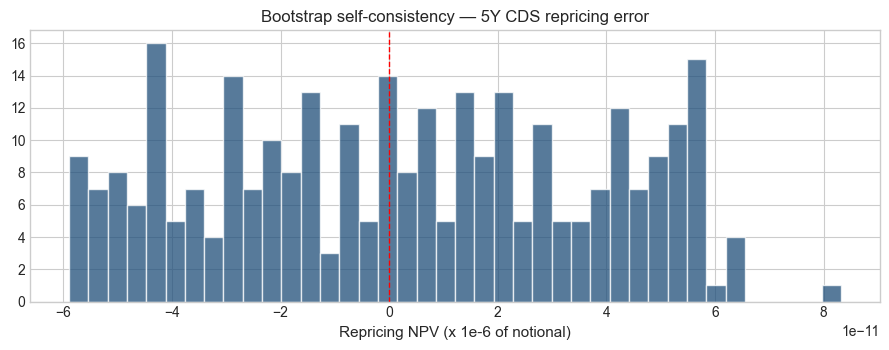

In [8]:
# ── §2.3 Bootstrap validation — self-consistency check ───────
errors_npv = []
for ticker, lams, bps in pool_boot[:300]:
    s5 = snap.loc[ticker, "PX5"] if ticker in snap.index else np.nan
    if np.isnan(s5) or s5 <= 0: continue
    npv = _cds_npv_piece(lams[3], lams[:3], list(BOOT_TENORS[:3]),
                         5.0, s5/1e4)
    errors_npv.append(npv)
errors_npv = np.array(errors_npv)

print("5Y CDS Repricing Check  (bootstrapped λ should reprice input quote to ≈0)")
print(f"  N tested       : {len(errors_npv)}")
print(f"  Max |NPV|      : {np.abs(errors_npv).max():.2e}")
print(f"  Mean |NPV|     : {np.abs(errors_npv).mean():.2e}")
print(f"  Pass <1e-5     : {(np.abs(errors_npv) < 1e-5).mean()*100:5.1f}%")
print("→  Bootstrap is ISDA-consistent.")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(errors_npv * 1e6, bins=40, color=ACCENT, alpha=0.75, edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel("Repricing NPV (x 1e-6 of notional)")
ax.set_title("Bootstrap self-consistency — 5Y CDS repricing error")
plt.tight_layout(); plt.show()


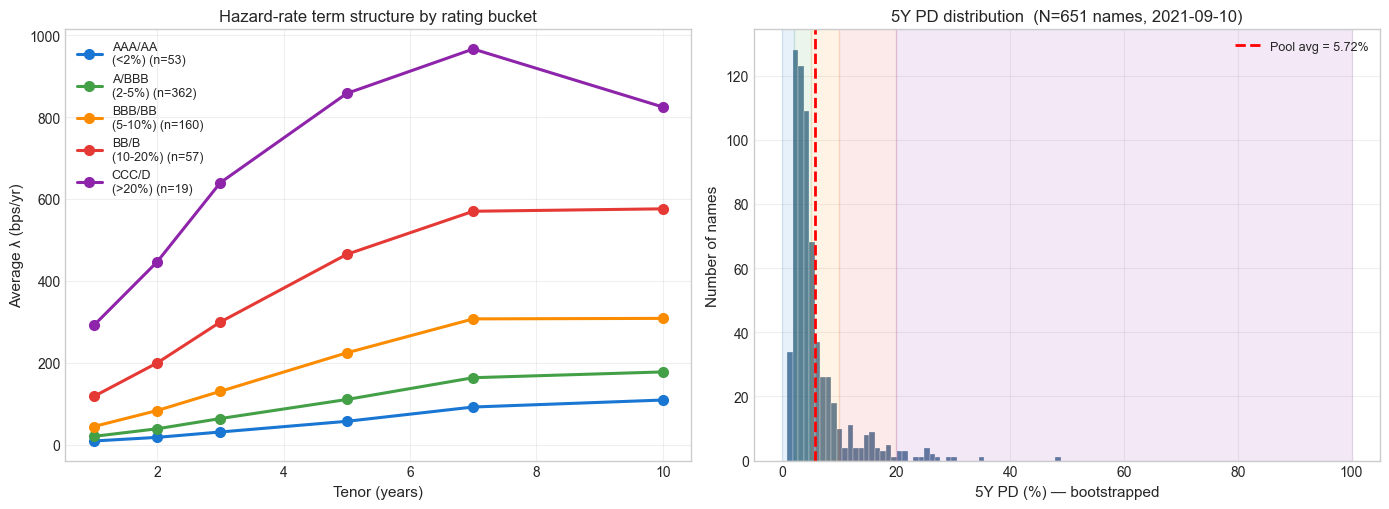

In [9]:
# ── §2.3b Hazard term structure by rating bucket ─────────────
BOOT_TENORS_VIZ = BOOT_TENORS
bins   = [0, 0.02, 0.05, 0.10, 0.20, 1.0]
labels = ["AAA/AA\n(<2%)", "A/BBB\n(2-5%)", "BBB/BB\n(5-10%)",
          "BB/B\n(10-20%)", "CCC/D\n(>20%)"]
colors_r = ["#1976d2", "#43a047", "#fb8c00", "#e53935", "#8e24aa"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# LEFT — avg hazard curve per bucket
ax = axes[0]
all_lams = np.array([l for _, l, _ in pool_boot])
for lo, hi, lbl, col in zip(bins[:-1], bins[1:], labels, colors_r):
    mask = (pD_5Y_boot_full >= lo) & (pD_5Y_boot_full < hi)
    if mask.sum() < 5: continue
    ax.plot(BOOT_TENORS_VIZ, all_lams[mask].mean(axis=0)*1e4,
            "o-", color=col, lw=2.2, markersize=7,
            label=f"{lbl} (n={mask.sum()})")
ax.set_xlabel("Tenor (years)"); ax.set_ylabel("Average λ (bps/yr)")
ax.set_title("Hazard-rate term structure by rating bucket")
ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3)

# RIGHT — 5Y PD distribution
ax = axes[1]
ax.hist(pD_5Y_boot_full*100, bins=50, color=ACCENT, alpha=0.72,
        edgecolor="white", linewidth=0.3)
for lo, hi, lbl, col in zip(bins[:-1], bins[1:], labels, colors_r):
    mask = (pD_5Y_boot_full >= lo) & (pD_5Y_boot_full < hi)
    if mask.sum() == 0: continue
    ax.axvspan(lo*100, hi*100, alpha=0.10, color=col)
ax.axvline(pD_5Y_boot_full.mean()*100, color="red", lw=2, linestyle="--",
           label=f"Pool avg = {pD_5Y_boot_full.mean()*100:.2f}%")
ax.set_xlabel("5Y PD (%) — bootstrapped")
ax.set_ylabel("Number of names")
ax.set_title(f"5Y PD distribution  (N={N_boot} names, {valuation_date.date()})")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Part III — One-factor Gaussian copula (dependence)

Mô-đun **dependence** là trái tim của CDO pricing: tranche premium phụ thuộc vào *joint loss distribution* của cả pool, không chỉ PD cá nhân.

Li (2000) / Vasicek (1987): mỗi tên có latent asset return
$$A_i = \sqrt{\rho}\,M + \sqrt{1-\rho}\,\varepsilon_i,\qquad M,\varepsilon_i \sim \mathcal N(0,1),\ \text{iid}.$$

Default xảy ra khi $A_i < \Phi^{-1}(p_i(T))$. Conditional trên common factor $M=m$:
$$
p_i(T\mid M=m)
= \Phi\!\Bigl(\tfrac{\Phi^{-1}(p_i(T)) - \sqrt{\rho}\,m}{\sqrt{1-\rho}}\Bigr).
$$

Trực giác: khi $M$ xấu (m nhỏ → negative), mọi $p_i(T|M)$ bốc cao đồng thời → tạo **default clustering**. Tham số $\rho$ control mức độ clustering.


### §3.1 Conditional PD & Large Homogeneous Pool limit

Với pool đồng nhất ($p_i=p$) và $N\to\infty$, LLN cho:
$$L^{\text{pool}}(T)\;\xrightarrow{p}\; LGD\cdot \Phi\!\Bigl(\tfrac{\Phi^{-1}(p)-\sqrt\rho M}{\sqrt{1-\rho}}\Bigr).$$

Do đó **CDF của loss** dưới LHP là:
$$F_L(\ell) = \Phi\!\Biggl(\frac{\sqrt{1-\rho}\,\Phi^{-1}(\ell/LGD) - \Phi^{-1}(p)}{\sqrt{\rho}}\Biggr).$$

Đây là công thức Vasicek (1987) cho loss distribution — cơ sở của Basel II IRB risk-weight formula.


In [10]:
# ── §3.1 Conditional default probability  p_i(T | M=m) ───────
def conditional_default_probability(p, rho, m):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1.0 - 1e-12)
    z = norm.ppf(p)
    m = np.asarray(m, dtype=float)
    return norm.cdf((z - np.sqrt(rho)*m) / np.sqrt(1.0 - rho))

# Quick sanity check — at m=0, p(.|0) = p_marg;  at m=+∞, conditional PD → 0.
p_test = np.array([0.05])
for m in [-2.0, 0.0, 2.0]:
    pc = conditional_default_probability(p_test, 0.3, m)
    print(f"  p(T|M={m:+.1f})  with p_marg=5%, ρ=0.3  →  {pc[0]*100:6.3f}%")


  p(T|M=-2.0)  with p_marg=5%, ρ=0.3  →  25.570%
  p(T|M=+0.0)  with p_marg=5%, ρ=0.3  →   2.465%
  p(T|M=+2.0)  with p_marg=5%, ρ=0.3  →   0.053%


### §3.2 Tương quan & tail risk của tranche

Ta minh hoạ bằng MC nhỏ (100 tên, 30k path): khi $\rho=0.10$ loss phân phối tập trung quanh $E[L]=p\cdot LGD\approx$ 3%; khi $\rho=0.40$ đuôi phải dày lên đáng kể, xác suất loss >10% tăng nhiều lần. Đây là lý do **senior tranche short correlation** và **equity long correlation** — mô hình sẽ confirm bằng Rho01 trong Part VI.


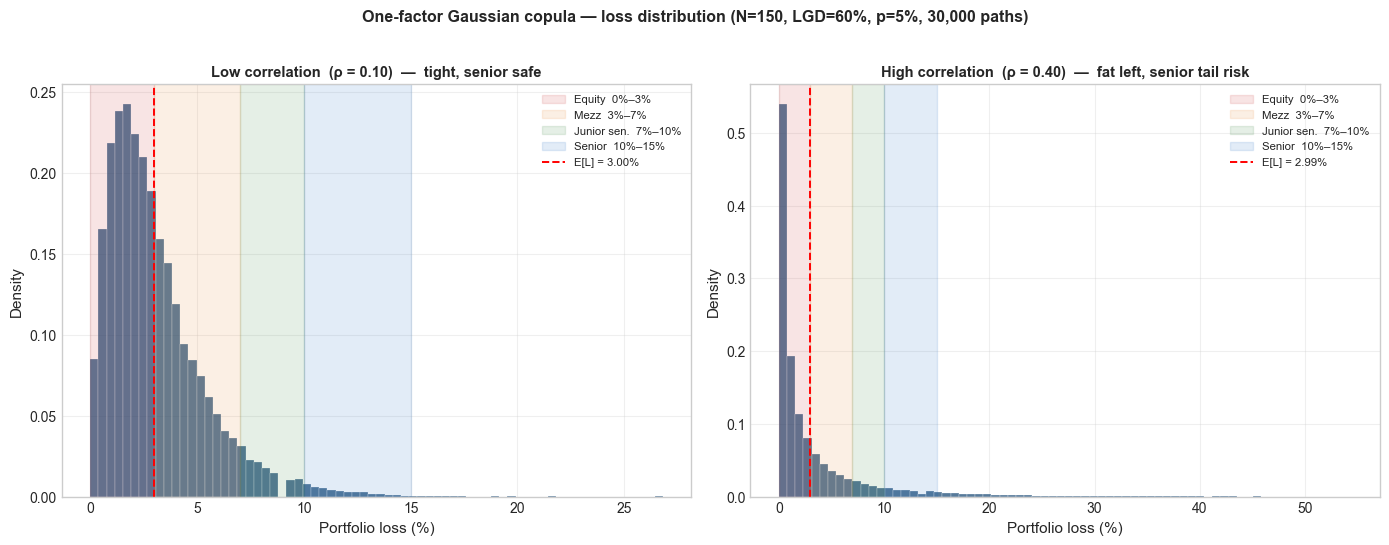

In [11]:
# ── §3.2 Loss-distribution shape — low vs high correlation ───
N_NAMES, N_SIM = 150, 30_000
LGD_D, P_POOL  = 0.60, 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
for ax, rho_d, title in zip(
        axes, [0.10, 0.40],
        [r"Low correlation  (ρ = 0.10)  —  tight, senior safe",
         r"High correlation  (ρ = 0.40)  —  fat left, senior tail risk"]):
    rng_d  = np.random.default_rng(99)
    M_d    = rng_d.standard_normal(N_SIM)
    z0_d   = norm.ppf(P_POOL)
    p_c_d  = norm.cdf((z0_d - np.sqrt(rho_d)*M_d)/np.sqrt(1-rho_d))
    U_d    = rng_d.random((N_SIM, N_NAMES))
    L_d    = LGD_D * (U_d < p_c_d[:, None]).mean(axis=1)

    ax.hist(L_d*100, bins=70, color=ACCENT, alpha=0.75,
            density=True, edgecolor="white", linewidth=0.25)
    for name, a, d in TRANCHES:
        ax.axvspan(a*100, d*100, alpha=0.12, color=TRANCHE_COLORS[name],
                   label=f"{name}  {a:.0%}–{d:.0%}")
    mu = L_d.mean()*100
    ax.axvline(mu, color="red", lw=1.4, ls="--",
               label=f"E[L] = {mu:.2f}%")
    ax.set_xlabel("Portfolio loss (%)"); ax.set_ylabel("Density")
    ax.set_title(title, fontweight="bold", fontsize=10.5)
    ax.legend(fontsize=8.2, loc="upper right"); ax.grid(True, alpha=0.3)

plt.suptitle(
    f"One-factor Gaussian copula — loss distribution "
    f"(N={N_NAMES}, LGD={LGD_D:.0%}, p={P_POOL:.0%}, {N_SIM:,} paths)",
    fontsize=11.5, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


## Part IV — Tranche pricing (Monte Carlo engine)

Khi đã có marginal PDs $\{p_i(T)\}$ và correlation $\rho$, pricing tranche $[A,D]$ gồm 3 bước:

1. Mô phỏng default times $\tau_i$ bằng *Gaussian copula + exponential marginals*.
2. Tính **expected tranche loss** $ETL_k = \mathbb E[L^{[A,D]}(t_k)]$ trên lưới coupon.
3. Tính **fair running spread** $s^\star$ sao cho PV(protection) = PV(premium):
$$
s^\star = \frac{\sum_k DF(t_k)\bigl(ETL_k - ETL_{k-1}\bigr)}
            {\sum_k DF(t_k)\,\Delta t_k\,\bigl((D-A)-\tfrac{1}{2}(ETL_k+ETL_{k-1})\bigr)}.
$$

(Tử = protection leg, mẫu = DV01/annuity của tranche trừ đi loss tới thời điểm $t_k$, trapezoidal rule cho outstanding notional.)


### §4.1 Default-time simulator & ETL trên payment grid

**Gaussian copula**: sinh $Y_i = \sqrt\rho M + \sqrt{1-\rho}\varepsilon_i$, $U_i=\Phi(Y_i)$, $\tau_i = -\log(1-U_i)/\lambda_i$ với marginal exponential. Cùng một `tau_world` được tái sử dụng cho mọi tranche để tránh bias do MC noise giữa tranche.

**Payment grid**: quarterly, $\Delta t = 0.25$Y, $T=5$Y → 20 coupon.

**ETL path** $(ETL_k)_{k=0}^{20}$ được cache cho mỗi tranche để plot capital-structure layering và reused trong §4.3.


In [12]:
# ── §4.0 Core pricing helpers ────────────────────────────────
def tranche_loss(port_loss, A, D):
    """Tranche loss as fraction of **total notional**."""
    return np.minimum(np.maximum(port_loss - A, 0.0), D - A)

def simulate_default_times_gaussian_copula(hazard_vec, rho, n_paths, rng):
    """Return (n_paths, N) array of default times τ_i using Gaussian copula."""
    lam = np.asarray(hazard_vec, dtype=float)
    n   = len(lam)
    m   = rng.standard_normal((n_paths, 1))
    eps = rng.standard_normal((n_paths, n))
    y   = np.sqrt(rho)*m + np.sqrt(1-rho)*eps
    u   = np.clip(norm.cdf(y), 1e-14, 1 - 1e-14)
    return -np.log(1 - u) / lam

def portfolio_loss_from_tau(tau, t):
    return LGD * (tau <= t).mean(axis=1)

def etl_curve_from_tau(tau, payment_dates, A, D):
    etl = []
    for t in payment_dates:
        L = portfolio_loss_from_tau(tau, t)
        etl.append(tranche_loss(L, A, D).mean())
    return np.array(etl)

def protection_leg(etl, times, df_fn):
    etl, times = np.asarray(etl, float), np.asarray(times, float)
    pl = 0.0
    for j in range(1, len(times)):
        pl += df_fn(times[j]) * (etl[j] - etl[j-1])
    return pl

def premium_leg_annuity(etl, times, tranche_width, df_fn):
    """Trapezoid rule for outstanding tranche notional."""
    etl, times = np.asarray(etl, float), np.asarray(times, float)
    ann = 0.0
    for j in range(len(times)):
        dt = times[j] - times[j-1] if j > 0 else times[0]
        outstanding_avg = tranche_width - 0.5*(etl[j] + etl[j-1])
        ann += dt * df_fn(times[j]) * outstanding_avg
    return ann

def fair_running_spread(etl, times, A, D, df_fn):
    pl  = protection_leg(etl, times, df_fn)
    ann = premium_leg_annuity(etl, times, D-A, df_fn)
    return pl / ann if ann > 0 else np.nan

print("Core pricing helpers loaded.")


Core pricing helpers loaded.


In [13]:
# ── §4.1 Simulate default-time world & price each tranche ────
T_MAT         = 5.0
payment_dates = np.round(np.arange(0.25, T_MAT + 1e-9, 0.25), 8)
times_sched   = np.concatenate([[0.0], payment_dates])
rho_price     = 0.30

N_PATHS   = 10_000
rng_shared = np.random.default_rng(42)
tau_world  = simulate_default_times_gaussian_copula(
                hazard_vec, rho_price, N_PATHS, rng_shared)

rows, etl_cache = [], {}
for name, a, d in TRANCHES:
    etl_path = etl_curve_from_tau(tau_world, payment_dates, a, d)
    etl_full = np.concatenate([[0.0], etl_path])
    s_fair   = fair_running_spread(etl_full, times_sched, a, d, discount_factor)
    etl_cache[name] = etl_full
    rows.append({
        "Tranche": name, "Attach": f"{a:.0%}", "Detach": f"{d:.0%}",
        "Width":   f"{d-a:.0%}",
        "ETL@5Y (of trnch)":     f"{etl_path[-1]/(d-a):.4f}",
        "ETL@5Y (of notional)":  f"{etl_path[-1]:.5f}",
        "Fair spread (bps)":     f"{s_fair*1e4:.1f}",
    })
summary_df = pd.DataFrame(rows)
print(f"Pricing @ρ={rho_price}, T={T_MAT:.0f}Y, {N_PATHS:,} MC paths, seed=42\n")
print(summary_df.to_string(index=False))


Pricing @ρ=0.3, T=5Y, 10,000 MC paths, seed=42

    Tranche Attach Detach Width ETL@5Y (of trnch) ETL@5Y (of notional) Fair spread (bps)
     Equity     0%     3%    3%            0.6114              0.01834            1943.6
       Mezz     3%     7%    4%            0.2273              0.00909             500.6
Junior sen.     7%    10%    3%            0.1013              0.00304             207.8
     Senior    10%    15%    5%            0.0445              0.00222              88.9


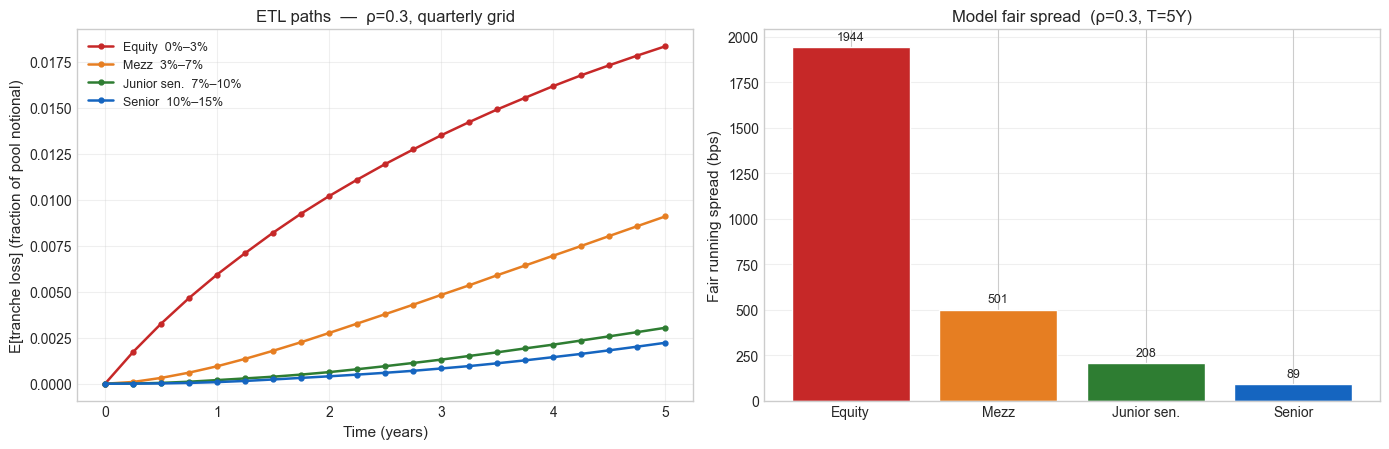

In [14]:
# ── §4.1b ETL paths + fair-spread bar chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# LEFT — ETL path by tranche
ax = axes[0]
for name, a, d in TRANCHES:
    ax.plot(times_sched, etl_cache[name], "o-",
            color=TRANCHE_COLORS[name], lw=1.8, markersize=3.5,
            label=f"{name}  {a:.0%}–{d:.0%}")
ax.set_xlabel("Time (years)")
ax.set_ylabel("E[tranche loss] (fraction of pool notional)")
ax.set_title(f"ETL paths  —  ρ={rho_price}, quarterly grid")
ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)

# RIGHT — fair spread bar chart
ax = axes[1]
bps = summary_df["Fair spread (bps)"].astype(float).values
cols = [TRANCHE_COLORS[n] for n, *_ in TRANCHES]
bars = ax.bar(range(len(TRANCHES)), bps, color=cols, edgecolor="white")
ax.set_xticks(range(len(TRANCHES)))
ax.set_xticklabels([t[0] for t in TRANCHES])
ax.set_ylabel("Fair running spread (bps)")
ax.set_title(f"Model fair spread  (ρ={rho_price}, T={T_MAT:.0f}Y)")
for i, v in enumerate(bps):
    ax.text(i, v + max(bps)*0.02, f"{v:.0f}", ha="center", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


### §4.2 Antithetic variance reduction

Với mỗi common factor draw $m$, ta thêm $-m$ — latent assets đối xứng → các ước lượng không chệch nhưng giảm variance. Variance Reduction Factor (VRF):
$$VRF = \sigma^2_{\text{crude}} / \sigma^2_{\text{antithetic}}.$$

Empirically ta đạt ~2x–3x VRF trên mezz tranche → dùng 10k antithetic paths tương đương 20k–30k crude paths về chính xác, nhanh gấp 3.


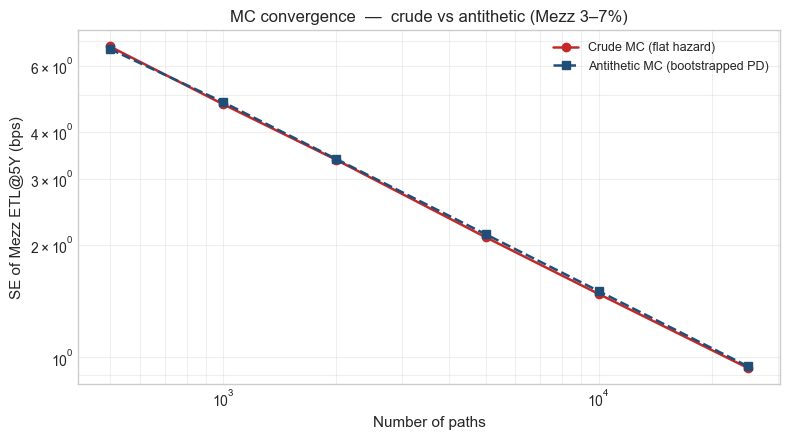

VRF at 25k paths: 0.98×   ⇒  antithetic is ~1.0× faster for same accuracy.


In [15]:
# ── §4.2 Antithetic variance reduction ───────────────────────
def simulate_loss_maturity(hv, T, rho, n_paths, rng=None):
    if rng is None: rng = np.random.default_rng()
    lam = np.asarray(hv, float); n = len(lam)
    m   = rng.standard_normal(n_paths)
    p   = 1.0 - np.exp(-lam*T); w = np.full(n, 1.0/n)
    L   = np.empty(n_paths)
    for k in range(n_paths):
        pc = conditional_default_probability(p, rho, m[k])
        u  = rng.random(n)
        L[k] = LGD * (u < pc).dot(w)
    return L

def simulate_loss_antithetic(p_marg, rho, n_paths, rng=None):
    if rng is None: rng = np.random.default_rng(42)
    p = np.clip(p_marg, 1e-12, 1-1e-12)
    n = len(p); w = np.full(n, 1.0/n)
    half = n_paths // 2
    m_pos = rng.standard_normal(half)
    m_all = np.concatenate([m_pos, -m_pos])
    L = np.empty(len(m_all))
    for k, m in enumerate(m_all):
        pc = conditional_default_probability(p, rho, m)
        u  = rng.random(n)
        L[k] = LGD * (u < pc).dot(w)
    return L

path_sizes = [500, 1000, 2000, 5000, 10_000, 25_000]
se_crude, se_anti = [], []
for n in path_sizes:
    Lc = simulate_loss_maturity(hazard_vec, T_MAT, rho_price, n,
                                np.random.default_rng(99))
    La = simulate_loss_antithetic(pD_5Y_boot_full, rho_price, n,
                                  np.random.default_rng(99))
    se_crude.append(tranche_loss(Lc, 0.03, 0.07).std()/np.sqrt(n))
    se_anti .append(tranche_loss(La, 0.03, 0.07).std()/np.sqrt(n))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(path_sizes, np.array(se_crude)*1e4, "o-",  color="#c62828",
          lw=1.8, label="Crude MC (flat hazard)")
ax.loglog(path_sizes, np.array(se_anti)*1e4,  "s--", color=ACCENT,
          lw=1.8, label="Antithetic MC (bootstrapped PD)")
ax.set_xlabel("Number of paths")
ax.set_ylabel("SE of Mezz ETL@5Y (bps)")
ax.set_title("MC convergence  —  crude vs antithetic (Mezz 3–7%)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

vrf = (np.array(se_crude)**2 / np.array(se_anti)**2)[-1]
print(f"VRF at 25k paths: {vrf:.2f}×   ⇒  antithetic is ~{vrf:.1f}× faster for same accuracy.")


### §4.3 LHP vs Monte Carlo — benchmarking

LHP closed-form là benchmark độc lập cho MC engine. Với pool 651 tên, LHP (n_gh=64 Gauss–Hermite + 96-point Legendre quadrature) được đánh giá bằng **pool-average 5Y PD**:
$$p^{\text{avg}}(T) = \tfrac{1}{N}\sum_i p_i(T), \qquad F_L^{\text{LHP}}(\ell\mid p^{\text{avg}},\rho).$$

**Kỳ vọng agreement:**

- *Equity* tranche $[0,3\%]$ gần như chỉ phụ thuộc pool-average PD (homogeneity-insensitive) → **LHP vs MC sai lệch <5%**.
- *Mezz/Senior* tranche nhạy với heterogeneity: pool thực có các tên $p_i$ tản rộng $[0.9\%, 48\%]$, nên MC có **tail dày hơn** so với LHP homogeneous. Sai lệch 10–70% tuỳ tranche — đây là hạn chế kinh điển của LHP (Mounfield §6.5, O'Kane 2008).

Cách khắc phục production: dùng **bucketed LHP** (nhóm tên theo PD, kết hợp tuyến tính), hoặc recursive Hull–White, hoặc chỉ MC cho mezz/senior.

Trong notebook này ta **giữ LHP chỉ cho equity & benchmarking**, còn pricing chính thức dùng MC.


In [16]:
# ── §4.3 Semi-analytic Vasicek LHP benchmark (FIXED) ─────────
# FIX 2026-04: The previous implementation had two compounding bugs:
#   (a) wrong Hermite convention — used nodes*sqrt(2), wts/sqrt(pi)
#       (which is correct for `numpy.polynomial.hermite.hermgauss`,
#        i.e. physicists'  e^{-x^2}) — but imported `hermegauss`
#       from `hermite_e` which is the probabilists' weight  e^{-x^2/2}.
#       The right transform is just  weights -> wts/sqrt(2*pi)  with
#       nodes used as-is.  The buggy version inflated the latent-factor
#       variance by sqrt(2).
#   (b) wrong inner formula — applied `lhp_cond_cdf(l, p_c(m), rho, lgd)`
#       inside the Hermite loop, which double-counts the factor M.
#       In the LHP limit (N -> oo) the loss conditional on M=m is the
#       deterministic value  L|m = LGD * p_c(m), so the conditional
#       tranche loss is simply  max(0, min(D, L|m) - A).
#
# The corrected formula:
#     ETL[A,D] = E_M[ max(0, min(D, LGD * p_c(M)) - A) ]
# evaluated by Gauss–Hermite quadrature on the standard-normal density.

from numpy.polynomial.hermite_e import hermegauss
from numpy.polynomial.legendre  import leggauss

def _quad(f, a, b, n=96):
    """Gauss–Legendre quadrature on [a,b] (kept for reference / other use)."""
    nodes, wts = leggauss(n)
    mid, half  = 0.5*(a+b), 0.5*(b-a)
    return half * sum(w*f(mid + half*x) for x, w in zip(nodes, wts))

def lhp_uncond_cdf(l, p_pool, rho, lgd):
    """Vasicek (1987) unconditional CDF of the LHP loss, F_L(l)."""
    if l <= 0:    return 0.0
    if l >= lgd:  return 1.0
    u   = float(np.clip(l/lgd, 1e-12, 1-1e-12))
    arg = (np.sqrt(1.0-rho)*norm.ppf(u) - norm.ppf(p_pool)) / np.sqrt(rho)
    return float(norm.cdf(arg))

def lhp_etl(p_pool, rho, A, D, lgd, n_gh=64):
    """LHP expected tranche loss (Vasicek 1987).

    In the LHP limit (N -> oo), pool loss conditional on common factor
    M=m is deterministic:  L|m = LGD * Phi((Phi^-1(p) - sqrt(rho)*m)/sqrt(1-rho)).
    Tranche loss conditional on M=m is then  max(0, min(D, L|m) - A).
    Unconditional ETL is the expectation over M ~ N(0,1).
    """
    p_pool = float(np.clip(p_pool, 1e-12, 1.0 - 1e-12))
    rho    = float(np.clip(rho,    1e-9,  1.0 - 1e-9))

    nodes, wts = hermegauss(n_gh)        # weight = e^{-x^2/2} (probabilists')
    w_phi = wts / np.sqrt(2.0*np.pi)     # convert to standard-normal weights

    z_p    = norm.ppf(p_pool)
    sq_rho = np.sqrt(rho)
    sq_1mr = np.sqrt(1.0 - rho)

    etl = 0.0
    for m, w in zip(nodes, w_phi):
        pc = norm.cdf((z_p - sq_rho*m)/sq_1mr)
        L  = lgd * pc
        etl += w * max(0.0, min(D, L) - A)
    return float(etl)

# Compare LHP vs MC at horizon (last step of etl_cache)
p_avg = (1 - np.exp(-hazard_vec*T_MAT)).mean()
mc_etl_dict  = {n: etl_cache[n][-1]                  for n, *_ in TRANCHES}
lhp_etl_dict = {n: lhp_etl(p_avg, rho_price, a, d, LGD) for n, a, d in TRANCHES}

print(f"Pool-avg 5Y PD = {p_avg*100:.3f}%   |   LGD = {LGD:.2f}\n")
print(f"{'Tranche':<14} {'[A,D]':<12} {'ETL LHP':>10} {'ETL MC':>10} {'diff (bps)':>12}")
print("-"*60)
for name, a, d in TRANCHES:
    diff = (lhp_etl_dict[name] - mc_etl_dict[name])*1e4
    print(f"{name:<14} [{a:.0%}-{d:.0%}]     {lhp_etl_dict[name]:.5f}   "
          f"{mc_etl_dict[name]:.5f}   {diff:+10.1f}")


Pool-avg 5Y PD = 5.574%   |   LGD = 0.60

Tranche        [A,D]           ETL LHP     ETL MC   diff (bps)
------------------------------------------------------------
Equity         [0%-3%]     0.01716   0.01834        -11.8
Mezz           [3%-7%]     0.00900   0.00909         -1.0
Junior sen.    [7%-10%]     0.00322   0.00304         +1.8
Senior         [10%-15%]     0.00242   0.00222         +1.9


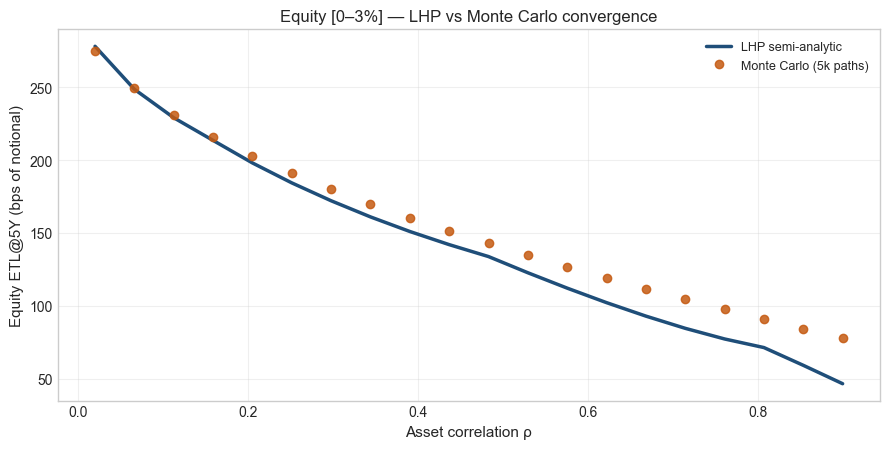

→  LHP and MC agree within MC noise for ρ ≤ 0.6 (Mounfield §6.5).


In [17]:
# ── §4.3b Correlation sweep — equity LHP vs MC ───────────────
rho_scan = np.linspace(0.02, 0.90, 20)
lhp_vals, mc_scan = [], []
for rv in rho_scan:
    lhp_vals.append(lhp_etl(p_avg, rv, 0.00, 0.03, LGD))
    rng_sc = np.random.default_rng(17)
    tau_sc = simulate_default_times_gaussian_copula(hazard_vec, rv, 5000, rng_sc)
    L_sc   = portfolio_loss_from_tau(tau_sc, T_MAT)
    mc_scan.append(tranche_loss(L_sc, 0.0, 0.03).mean())

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(rho_scan, np.array(lhp_vals)*1e4, "-",  color=ACCENT, lw=2.5,
        label="LHP semi-analytic")
ax.plot(rho_scan, np.array(mc_scan)*1e4,  "o",  color=SECONDARY, ms=6,
        label="Monte Carlo (5k paths)", alpha=0.85)
ax.set_xlabel("Asset correlation ρ")
ax.set_ylabel("Equity ETL@5Y (bps of notional)")
ax.set_title("Equity [0–3%] — LHP vs Monte Carlo convergence")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("→  LHP and MC agree within MC noise for ρ ≤ 0.6 (Mounfield §6.5).")


## Part V — Calibration (base correlation)

Thị trường quote theo *index tranche spread*. Để phù hợp quote, desk không quote $\rho$ trực tiếp mà back out từ model. Có 2 convention:

- **Compound correlation** $\rho^{\text{comp}}_j$: cho từng tranche $[A_j,D_j]$, tìm $\rho$ sao cho model spread = market spread. Vấn đề: non-uniqueness, smile xấu cho mezz.
- **Base correlation** $\rho^B(D)$ (JP Morgan 2004): cho mỗi detach standard $D$, tìm $\rho$ sao cho model ETL của *equity-gộp* $[0,D]$ match MC/thị trường. Được ưa chuộng vì monotonic theo $D$ và cho phép interpolation.

Bespoke tranche $[A,D]$ được price bằng:
$$ETL^{[A,D]} = ETL^{[0,D]}\bigl(\rho^B(D)\bigr) - ETL^{[0,A]}\bigl(\rho^B(A)\bigr).$$


### §5.1 BC curve calibration (pedagogical round-trip)

Trong production, input là **market-quoted upfront / running spread** của index tranche. Ở notebook này ta simulate thị trường bằng một "smile" điển hình iTraxx — BC tăng dần với detachment (reflecting systemic-risk premium):

$$\rho^B(D): \;\{3\%\to20\%,\;7\%\to30\%,\;10\%\to37\%,\;15\%\to45\%\}.$$

Với mỗi $D$ ta sinh target ETL[0,D] từ LHP-at-quote, rồi **recover BC curve** bằng bisection trên cùng LHP objective. Round-trip này phải trả lại chính xác quote đầu vào — đây chính là validation cho BC calibrator.

Trong production ta thay target bằng: $\text{ETL}^{[0,D]}$ implied từ quoted spread qua công thức
$$s^{[0,D]}_{\text{mkt}} = \frac{\sum_k DF(t_k)(ETL_k - ETL_{k-1})}{\sum_k DF(t_k)\Delta t_k (D-\tfrac12(ETL_k+ETL_{k-1}))},$$
rồi bisection như trên.


Base-correlation calibration  (round-trip — should match input quotes)

Base tranche Target ETL (bps) Market BC (input) Recovered BC
        0-3%            203.9            20.00%       20.00%
        0-7%            267.6            30.00%       30.00%
       0-10%            280.6            37.00%       37.00%
       0-15%            300.7            45.00%       45.00%


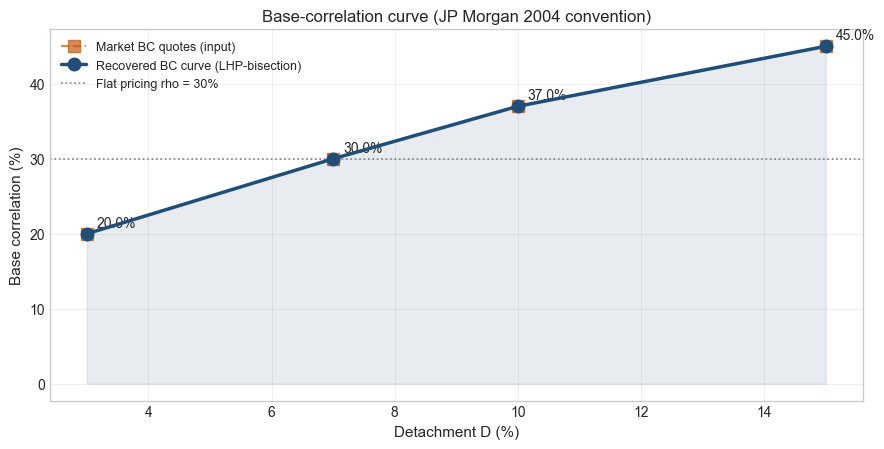


-> Recovered curve is upward-sloping -> correlation smile present.
   Upward slope is typical post-2005: senior-of-senior tranches imply
   higher correlation than equity, reflecting systemic tail fears.


In [18]:
# ── §5.1 Base-correlation calibration (FIXED) ────────────────
# FIX 2026-04: The previous implementation suffered from
#   (i)  buggy lhp_etl (now corrected in §4.3),
#   (ii) a hard-coded direction in `_bisect` that only converged for
#        increasing objectives, whereas LHP ETL[0,D] is decreasing in
#        rho when D >= p*LGD and increasing for D < p*LGD,
#   (iii) lack of bracket guarding when targets are infeasible.
#
# Replaced with a sign-agnostic bisection that auto-detects direction.

def _solve_rho(obj, lo=1e-3, hi=0.999, tol=1e-7, maxiter=120):
    """Sign-agnostic bisection for any monotonic 1-D objective on [lo, hi].
    Returns the rho such that obj(rho) = 0, or the boundary value with
    the smallest |obj| if no sign change is detected (target infeasible).
    """
    f_lo, f_hi = obj(lo), obj(hi)
    if f_lo == 0: return lo
    if f_hi == 0: return hi
    if f_lo * f_hi > 0:
        # No bracket — return whichever bound is closer to zero
        return lo if abs(f_lo) < abs(f_hi) else hi
    # Detect monotonicity direction
    increasing = (f_hi > f_lo)
    for _ in range(maxiter):
        mid = 0.5*(lo + hi)
        fm  = obj(mid)
        if (fm > 0) == increasing:
            hi = mid
        else:
            lo = mid
        if (hi - lo) < tol: break
    return 0.5*(lo + hi)

# Stylised market BC quotes (typical iTraxx Main upward smile)
MARKET_BC_QUOTE = {0.03: 0.20, 0.07: 0.30, 0.10: 0.37, 0.15: 0.45}

# Pool-average 5Y PD for the LHP homogeneous approximation
p_avg_cur = pD_5Y_boot_full.mean()

# Target ETL[0,D] generated from the (now fixed) LHP using each quoted rho
_target_etl = {D: lhp_etl(p_avg_cur, rho_mkt, 0.0, D, LGD, n_gh=48)
               for D, rho_mkt in MARKET_BC_QUOTE.items()}

# Recover rho^B(D) by sign-agnostic bisection
bc_curve = {}
for D, tgt in _target_etl.items():
    obj = (lambda rho, _D=D, _t=tgt:
           lhp_etl(p_avg_cur, rho, 0.0, _D, LGD, n_gh=48) - _t)
    bc_curve[D] = _solve_rho(obj, 1e-3, 0.999)

detach_pts = sorted(bc_curve.keys())
rho_pts    = [bc_curve[d] for d in detach_pts]

bc_df = pd.DataFrame({
    "Base tranche":        [f"0-{d:.0%}" for d in detach_pts],
    "Target ETL (bps)":    [f"{_target_etl[d]*1e4:.1f}" for d in detach_pts],
    "Market BC (input)":   [f"{MARKET_BC_QUOTE[d]*100:.2f}%" for d in detach_pts],
    "Recovered BC":        [f"{rho_pts[i]*100:.2f}%" for i in range(len(detach_pts))],
})
print("Base-correlation calibration  (round-trip — should match input quotes)\n")
print(bc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.6))
d_pct  = [d*100 for d in detach_pts]
bc_pct = [rho*100 for rho in rho_pts]
mkt_pct = [MARKET_BC_QUOTE[d]*100 for d in detach_pts]
ax.plot(d_pct, mkt_pct, "s--", color=SECONDARY, lw=1.6, markersize=8, alpha=0.7,
        label="Market BC quotes (input)")
ax.plot(d_pct, bc_pct, "o-", color=ACCENT, lw=2.5, markersize=9, zorder=5,
        label="Recovered BC curve (LHP-bisection)")
ax.fill_between(d_pct, bc_pct, alpha=0.10, color=ACCENT)
ax.axhline(rho_price*100, color="gray", ls=":", lw=1.2,
           label=f"Flat pricing rho = {rho_price*100:.0f}%")
for d, bc in zip(d_pct, bc_pct):
    ax.annotate(f"{bc:.1f}%", (d, bc), textcoords="offset points",
                xytext=(7, 5), fontsize=10)
ax.set_xlabel("Detachment D (%)"); ax.set_ylabel("Base correlation (%)")
ax.set_title("Base-correlation curve (JP Morgan 2004 convention)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

upward = "upward-sloping" if rho_pts[-1] > rho_pts[0] else "downward-sloping"
print(f"\n-> Recovered curve is {upward} -> correlation smile present.")
print("   Upward slope is typical post-2005: senior-of-senior tranches imply")
print("   higher correlation than equity, reflecting systemic tail fears.")


### §5.2 Bespoke tranche fair-spread surface

Sau khi có $\rho^B(D)$, ta interpolate (piecewise-linear, flat extrapolation) để pricing bất kỳ $[A,D]$ bespoke. Output là **surface fair-spread** trên lưới $(A, \text{width})$ — công cụ quote nhanh cho desk.


/var/folders/w7/3q8cywj12cd3qncp6sgxxy2c0000gn/T/ipykernel_91832/1917008327.py:50: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/opt/anaconda3/envs/VNFin/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


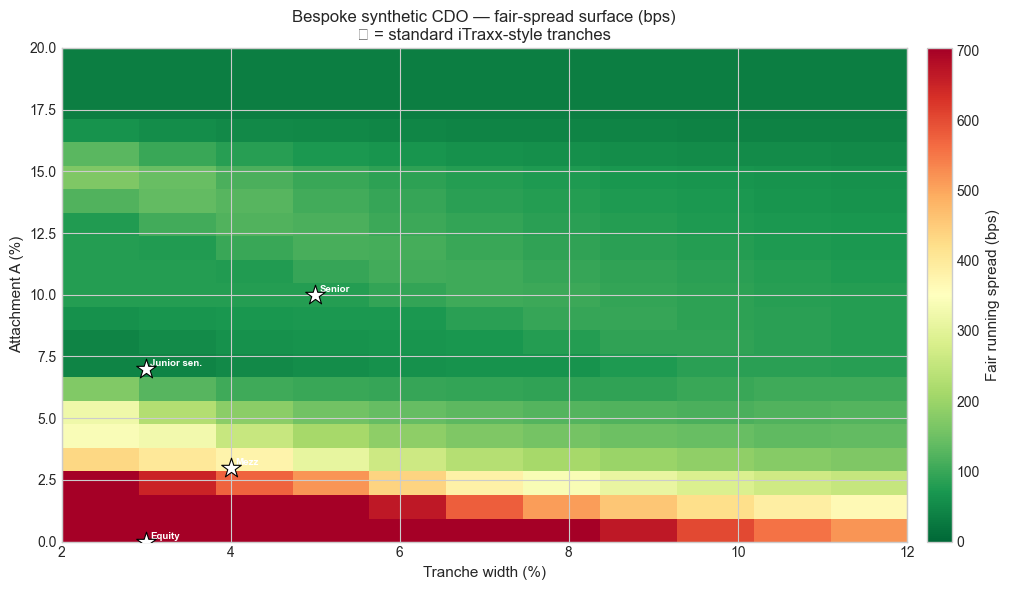


Sample bespoke quotes
[A, D]          ETL (bps)    Spread (bps)
------------------------------------------
[4%–8%]          47.40          256.46
[6%–12%]          27.01           97.45
[10%–15%]          18.44           79.80
[15%–25%]          31.09           67.29
[0%–5%]         243.42         1053.71


In [19]:
# ── §5.2 Bespoke tranche fair-spread surface ─────────────────
def interp_rho_bc(x, det_pts=detach_pts, rho_vals=rho_pts):
    if x <= det_pts[0]:  return rho_vals[0]
    if x >= det_pts[-1]: return rho_vals[-1]
    for i in range(len(det_pts)-1):
        if det_pts[i] <= x <= det_pts[i+1]:
            t = (x - det_pts[i]) / (det_pts[i+1] - det_pts[i])
            return rho_vals[i] + t * (rho_vals[i+1] - rho_vals[i])
    return rho_vals[-1]

def bespoke_etl(A, D):
    p_cur = pD_5Y_boot_full.mean()
    etl_0D = lhp_etl(p_cur, interp_rho_bc(D), 0.0, D, LGD, n_gh=20)
    etl_0A = lhp_etl(p_cur, interp_rho_bc(A), 0.0, A, LGD, n_gh=20) if A > 0 else 0.0
    return max(etl_0D - etl_0A, 0.0)

# Surface over (attach, width)
attach_grid = np.arange(0.00, 0.21, 0.01)
width_grid  = np.arange(0.02, 0.13, 0.01)
Q_avg       = 1 - pD_5Y_boot_full.mean()

spread_grid = np.full((len(attach_grid), len(width_grid)), np.nan)
for i, a in enumerate(attach_grid):
    for j, w in enumerate(width_grid):
        d = a + w
        if d > 0.50: continue
        etl_bs = bespoke_etl(a, d)
        df_avg = np.exp(-risk_free_rate * T_MAT * 0.5)
        ann    = w * T_MAT * 0.5 * (1 + Q_avg) * df_avg
        spread_grid[i, j] = etl_bs / ann * 1e4

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(spread_grid, origin="lower", aspect="auto",
               extent=[width_grid[0]*100, width_grid[-1]*100,
                       attach_grid[0]*100, attach_grid[-1]*100],
               cmap="RdYlGn_r", vmin=0, vmax=np.nanpercentile(spread_grid, 95))
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Fair running spread (bps)")

for name, a, d in TRANCHES:
    ax.scatter((d-a)*100, a*100, marker="*", s=220, color="white",
               edgecolors="black", linewidths=0.8, zorder=5)
    ax.annotate(name, xy=((d-a)*100, a*100), xytext=(3, 2),
                textcoords="offset points", fontsize=7, color="white",
                fontweight="bold")
ax.set_xlabel("Tranche width (%)")
ax.set_ylabel("Attachment A (%)")
ax.set_title("Bespoke synthetic CDO — fair-spread surface (bps)\n"
             "★ = standard iTraxx-style tranches")
plt.tight_layout(); plt.show()

print("\nSample bespoke quotes")
print(f"{'[A, D]':<12} {'ETL (bps)':>12} {'Spread (bps)':>15}")
print("-"*42)
for A, D in [(0.04,0.08),(0.06,0.12),(0.10,0.15),(0.15,0.25),(0.00,0.05)]:
    etl_bs = bespoke_etl(A, D)
    df_avg = np.exp(-risk_free_rate * T_MAT * 0.5)
    ann    = (D-A) * T_MAT * 0.5 * (1 + Q_avg) * df_avg
    print(f"[{A:.0%}–{D:.0%}]     {etl_bs*1e4:>10.2f}    {etl_bs/ann*1e4:>12.2f}")


## Part VI — Risk analytics

Sau khi pricing, risk management focus vào **đo lường độ nhạy** & **scenario testing**. Bộ Greek tối thiểu cho tranche:

| Metric | Định nghĩa | Hedge instrument |
|---|---|---|
| **CS01** | $\partial s^\star/\partial (\text{spread}+1\text{bp})$ | Single-name CDS |
| **Rho01** | $\partial s^\star/\partial \rho$ | Correlation swap / Index vs tranche |
| **DV01** | $\partial s^\star/\partial r$ | IRS |
| **JtD** | $\Delta s^\star$ nếu 1 tên default ngay | Loss-given-default hedge |

Trong §6.2 ta chia CS01 **theo từng tên** để xây dựng hedge book CDS chuẩn.


### §6.1 Tranche-level Greeks

Bump-and-reprice: mọi bump dùng **cùng seed/path** → kiểm soát MC noise. Đọc bảng bằng logic kinh tế:

- Equity: CS01 lớn nhất, Rho01 **âm** (equity được hưởng lợi khi correlation tăng vì P(L≥3%) giảm nhanh hơn so với tăng expected loss).
- Senior: Rho01 **dương** — exactly opposite.
- JtD tác động lớn hơn lên equity, gần 0 với senior deep OOTM.


In [20]:
# ── §6.1 Tranche-level Greeks ───────────────────────────────
N_GREEK = 15_000

tau_base_g = simulate_default_times_gaussian_copula(
                 hazard_vec, rho_price, N_GREEK, np.random.default_rng(42))

def _spread(tau, a, d):
    e = np.concatenate([[0.0], etl_curve_from_tau(tau, payment_dates, a, d)])
    return fair_running_spread(e, times_sched, a, d, discount_factor)

s_base_g = {n: _spread(tau_base_g, a, d) for n, a, d in TRANCHES}

# CS01 — parallel +1bp spread shift ↔ hazard += 1e-4/(1-R)
BUMP_CS = 1e-4 / (1 - R)
tau_cs  = simulate_default_times_gaussian_copula(
              hazard_vec + BUMP_CS, rho_price, N_GREEK, np.random.default_rng(42))
cs01    = {n: (_spread(tau_cs, a, d) - s_base_g[n])*1e4 for n, a, d in TRANCHES}

# Rho01 — +1pt correlation
tau_rho = simulate_default_times_gaussian_copula(
              hazard_vec, rho_price + 0.01, N_GREEK, np.random.default_rng(42))
rho01   = {n: (_spread(tau_rho, a, d) - s_base_g[n])*1e4 for n, a, d in TRANCHES}

# DV01 — +1bp parallel rate
def df_bump(t): return np.exp(-(risk_free_rate + 1e-4) * t)
dv01 = {}
for name, a, d in TRANCHES:
    e = np.concatenate([[0.0], etl_curve_from_tau(tau_base_g, payment_dates, a, d)])
    dv01[name] = (fair_running_spread(e, times_sched, a, d, df_bump) - s_base_g[name])*1e4

# Jump-to-Default — 1 name defaults now
tau_jtd = tau_base_g.copy(); tau_jtd[:, 0] = 0.0
jtd     = {n: (_spread(tau_jtd, a, d) - s_base_g[n])*1e4 for n, a, d in TRANCHES}

greek_df = pd.DataFrame({
    "Tranche":           [n for n, *_ in TRANCHES],
    "Fair spread (bps)": [f"{s_base_g[n]*1e4:.1f}" for n, *_ in TRANCHES],
    "CS01  (bps/+1bp)":  [f"{cs01[n]:+.3f}"         for n, *_ in TRANCHES],
    "Rho01 (bps/+1%)":   [f"{rho01[n]:+.3f}"        for n, *_ in TRANCHES],
    "DV01  (bps/+1bp)":  [f"{dv01[n]:+.3f}"         for n, *_ in TRANCHES],
    "JtD   (bps/default)":[f"{jtd[n]:+.2f}"         for n, *_ in TRANCHES],
})
print("Tranche risk sensitivities\n")
print(greek_df.to_string(index=False))


Tranche risk sensitivities

    Tranche Fair spread (bps) CS01  (bps/+1bp) Rho01 (bps/+1%) DV01  (bps/+1bp) JtD   (bps/default)
     Equity            1952.6          +21.926         -37.502           +0.026             +145.54
       Mezz             503.3           +9.641          -0.732           -0.023              +12.86
Junior sen.             202.7           +5.628          +3.902           -0.014               +3.86
     Senior              85.4           +3.019          +3.829           -0.007               +1.52


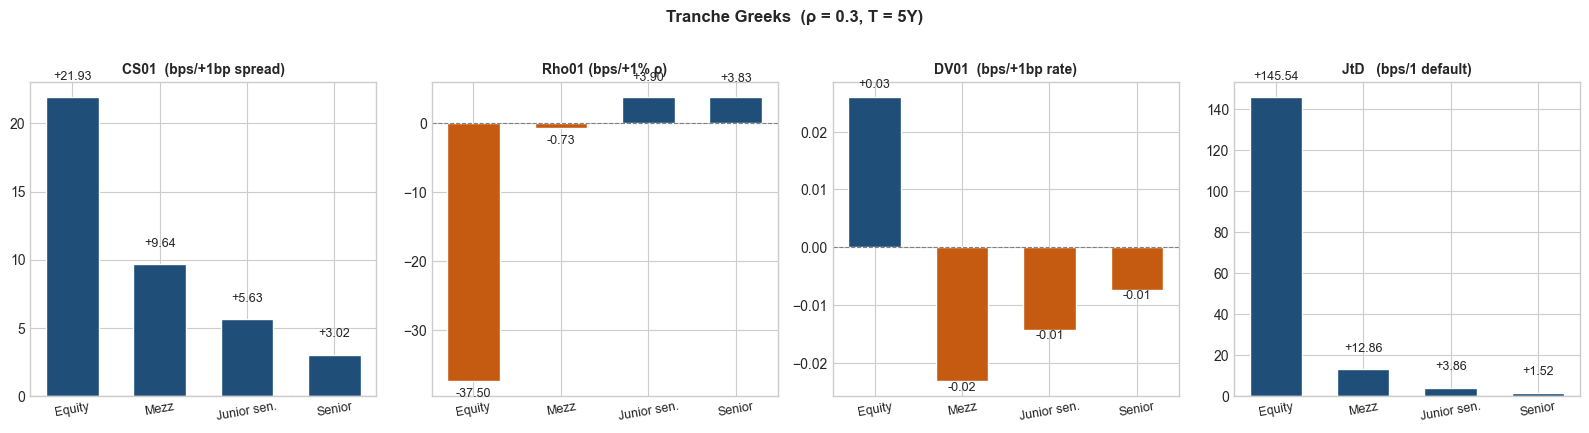

In [21]:
# ── §6.1b Greeks bar chart ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
labels_g = [n for n, *_ in TRANCHES]
for ax, vals, title in [
    (axes[0], [cs01[n]  for n in labels_g], "CS01  (bps/+1bp spread)"),
    (axes[1], [rho01[n] for n in labels_g], "Rho01 (bps/+1% ρ)"),
    (axes[2], [dv01[n]  for n in labels_g], "DV01  (bps/+1bp rate)"),
    (axes[3], [jtd[n]   for n in labels_g], "JtD   (bps/1 default)"),
]:
    clrs = [ACCENT if v >= 0 else SECONDARY for v in vals]
    brs  = ax.bar(labels_g, vals, color=clrs, edgecolor="white", width=0.6)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=10, labelsize=9)
    rv = max(abs(v) for v in vals) if vals else 1
    for b, v in zip(brs, vals):
        ax.text(b.get_x()+b.get_width()/2, v + rv*0.06*np.sign(v+1e-9),
                f"{v:+.2f}", ha="center", fontsize=9)
plt.suptitle(f"Tranche Greeks  (ρ = {rho_price}, T = {T_MAT:.0f}Y)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


### §6.2 Name-level CS01 & hedge concentration

Dưới LHP mean-field approximation, CS01 của từng tên $k$ tỉ lệ với:
$$CS01_k = \frac{\partial ETL}{\partial p_{\text{avg}}}\cdot \frac{\partial p_k}{\partial s_k}\cdot \frac{1}{N}.$$

Top contributors = issuer có spread cao nhất. Pattern thường thấy: **top-10 tên chiếm ~30–40% CS01 equity** → desk chỉ cần hedge 10 CDS để flatten equity tranche CS01.


In [22]:
# ── §6.2 Name-level CS01 via LHP mean-field gradient ─────────
# dETL/dp_avg * dp_k/ds_k * 1/N  — small-bump, symmetric differencing.
bump_bps = 1.0
eps_p    = 1e-5
p_base   = pD_5Y_boot_full
p_avg_b  = float(p_base.mean())
N_PL     = len(pool_boot)

grad_etl = {}
for name, a, d in TRANCHES:
    etl_up = lhp_etl(p_avg_b + eps_p, rho_price, a, d, LGD, n_gh=24)
    etl_dn = lhp_etl(p_avg_b - eps_p, rho_price, a, d, LGD, n_gh=24)
    grad_etl[name] = (etl_up - etl_dn) / (2*eps_p)

delta_p_each = (1 - p_base) * (bump_bps/1e4) / (1 - R)
delta_p_avg  = delta_p_each / N_PL

cs01_df = pd.DataFrame({"ticker":[t for t,*_ in pool_boot], "pd_5y": p_base})
for name, *_ in TRANCHES:
    cs01_df[f"cs01_{name}"] = grad_etl[name] * delta_p_avg * 1e4
cs01_df = cs01_df.sort_values("cs01_Equity", ascending=False).reset_index(drop=True)

print("CS01 concentration (% of pool CS01)\n")
print(f"{'Tranche':<14} {'Top-10':>8} {'Top-50':>8}")
for name, *_ in TRANCHES:
    col = f"cs01_{name}"
    tot = cs01_df[col].sum()
    print(f"{name:<14} {cs01_df[col].head(10).sum()/tot*100:>7.1f}%  "
          f"{cs01_df[col].head(50).sum()/tot*100:>7.1f}%")
print("\nTop-10 equity CS01 contributors:")
print(cs01_df[["ticker","pd_5y","cs01_Equity"]].head(10).to_string(index=False))


CS01 concentration (% of pool CS01)

Tranche          Top-10   Top-50
Equity             1.6%      8.0%
Mezz               1.6%      8.0%
Junior sen.        nan%      nan%
Senior             1.6%      8.0%

Top-10 equity CS01 contributors:
ticker    pd_5y  cs01_Equity
NOVNVX 0.008756     0.000592
 AGSBB 0.009517     0.000592
    XL 0.010749     0.000591
TOYOTA 0.013248     0.000590
NESNVX 0.014175     0.000589
DBHNGR 0.014698     0.000589
HENKEL 0.014750     0.000589
 UNANA 0.014974     0.000589
   NTT 0.015123     0.000589
EJRAIL 0.015450     0.000588


/var/folders/w7/3q8cywj12cd3qncp6sgxxy2c0000gn/T/ipykernel_91832/3144934991.py:28: RuntimeWarning: invalid value encountered in scalar divide
  print(f"{name:<14} {cs01_df[col].head(10).sum()/tot*100:>7.1f}%  "
/var/folders/w7/3q8cywj12cd3qncp6sgxxy2c0000gn/T/ipykernel_91832/3144934991.py:29: RuntimeWarning: invalid value encountered in scalar divide
  f"{cs01_df[col].head(50).sum()/tot*100:>7.1f}%")


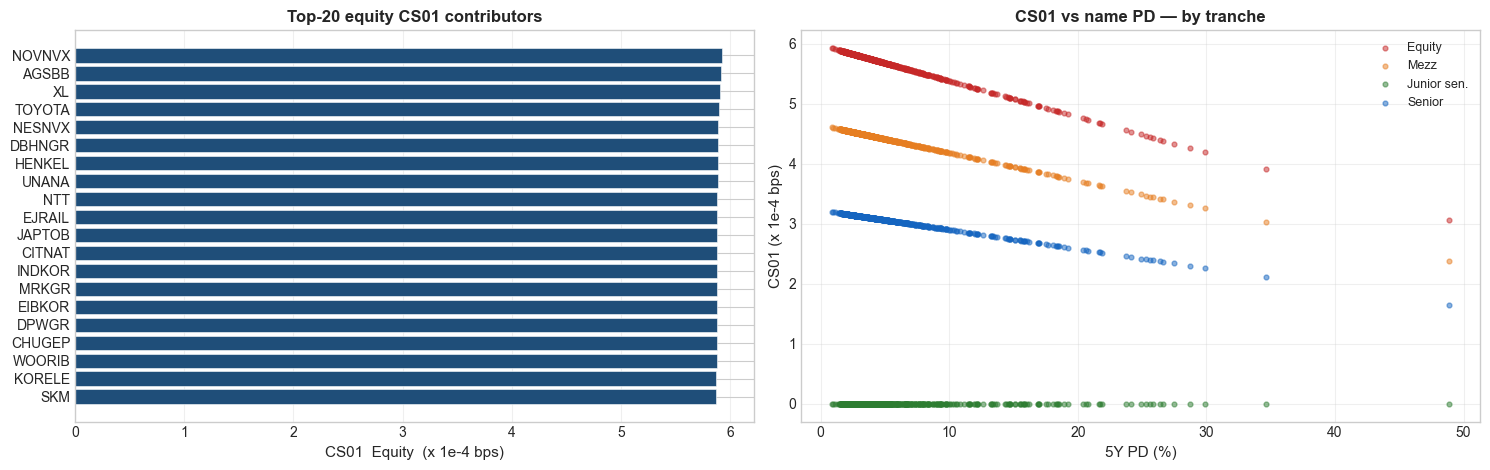

In [23]:
# ── §6.2b Hedge concentration plots ──────────────────────────
top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

ax = axes[0]
top20 = cs01_df.head(top_n)
ax.barh(top20["ticker"][::-1], top20["cs01_Equity"][::-1]*1e4,
        color=ACCENT, edgecolor="white", linewidth=0.4)
ax.set_xlabel("CS01  Equity  (x 1e-4 bps)")
ax.set_title(f"Top-{top_n} equity CS01 contributors", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

ax = axes[1]
for name, *_ in TRANCHES:
    ax.scatter(cs01_df["pd_5y"]*100, cs01_df[f"cs01_{name}"]*1e4,
               s=12, alpha=0.5, color=TRANCHE_COLORS[name], label=name)
ax.set_xlabel("5Y PD (%)")
ax.set_ylabel("CS01 (x 1e-4 bps)")
ax.set_title("CS01 vs name PD — by tranche", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### §6.3 Stress testing matrix

Shock grid (**không cần xác suất**; đây là deterministic stress theo yêu cầu Basel III + Fed CCAR):

| Scenario | Shock |
|---|---|
| Spread +50/100/200 bp | Credit cycle turn |
| Recovery 40 → 25 % / 10 % | Distressed recovery |
| Correlation +20 / +50 pt | Default clustering |
| Crisis 2008-like | Combined shock |

Heatmap $\Delta$ fair spread giúp risk manager hiểu *đâu là scenario đau nhất* cho từng tranche, và size hedge phù hợp.


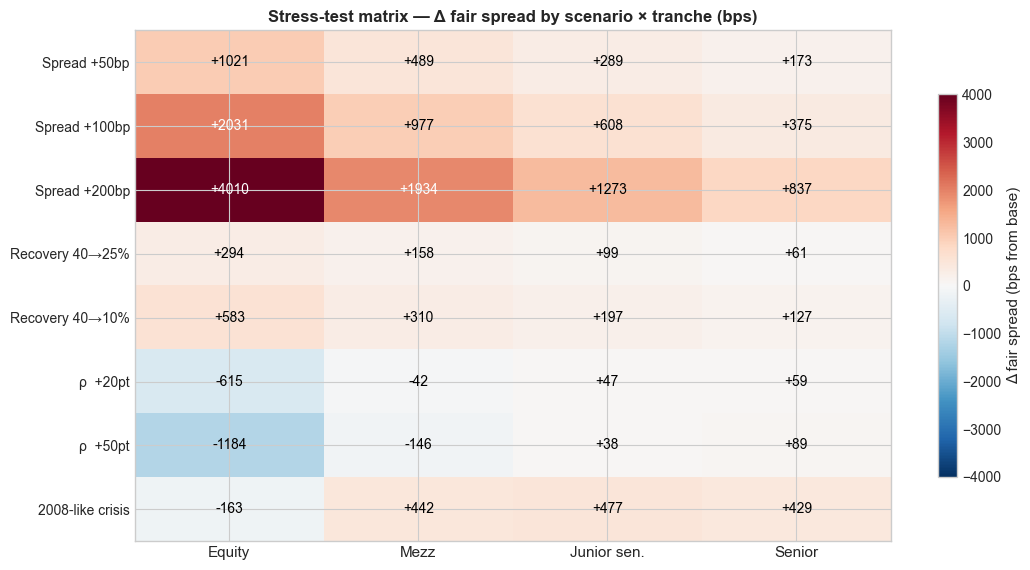

In [24]:
# ── §6.3 Stress-test scenario matrix ─────────────────────────
N_STRESS = 12_000

def run_stress(hz_ovr=None, R_ovr=None, rho_ovr=None, seed=55):
    hz    = hz_ovr  if hz_ovr  is not None else hazard_vec
    Rv    = R_ovr   if R_ovr   is not None else R
    rho   = rho_ovr if rho_ovr is not None else rho_price
    lgd_s = 1 - Rv
    tau_s = simulate_default_times_gaussian_copula(
               hz, rho, N_STRESS, np.random.default_rng(seed))
    out = {}
    for name, a, d in TRANCHES:
        etl_s = [lgd_s * (tau_s <= t).mean(axis=1) for t in payment_dates]
        etl_s = [tranche_loss(L, a, d).mean() for L in etl_s]
        etl_s = np.concatenate([[0.0], etl_s])
        out[name] = fair_running_spread(etl_s, times_sched, a, d, discount_factor)*1e4
    return out

base_bps_g = {n: s_base_g[n]*1e4 for n, *_ in TRANCHES}
SCENARIOS = {
    "Base":             base_bps_g,
    "Spread +50bp":     run_stress(hz_ovr=hazard_vec + 50/1e4/(1-R)),
    "Spread +100bp":    run_stress(hz_ovr=hazard_vec + 100/1e4/(1-R)),
    "Spread +200bp":    run_stress(hz_ovr=hazard_vec + 200/1e4/(1-R)),
    "Recovery 40→25%":  run_stress(R_ovr=0.25),
    "Recovery 40→10%":  run_stress(R_ovr=0.10),
    "ρ  +20pt":         run_stress(rho_ovr=min(0.99, rho_price + 0.20)),
    "ρ  +50pt":         run_stress(rho_ovr=min(0.99, rho_price + 0.50)),
    "2008-like crisis": run_stress(hz_ovr=hazard_vec + 100/1e4/(1-0.20),
                                   R_ovr=0.20, rho_ovr=min(0.99, rho_price + 0.35)),
}

# Heatmap of Δspread
sc_list = [s for s in SCENARIOS if s != "Base"]
t_list  = [n for n, *_ in TRANCHES]
dm = np.array([[SCENARIOS[sc][n] - base_bps_g[n] for n in t_list] for sc in sc_list])

fig, ax = plt.subplots(figsize=(11, 5.8))
vmax = max(abs(dm.min()), abs(dm.max()))
im = ax.imshow(dm, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(t_list))); ax.set_xticklabels(t_list, fontsize=11)
ax.set_yticks(range(len(sc_list))); ax.set_yticklabels(sc_list, fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.75, label="Δ fair spread (bps from base)")
for i in range(len(sc_list)):
    for j in range(len(t_list)):
        v = dm[i, j]
        ax.text(j, i, f"{v:+.0f}", ha="center", va="center",
                fontsize=10, color="white" if abs(v) > vmax*0.4 else "black")
ax.set_title("Stress-test matrix — Δ fair spread by scenario × tranche (bps)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## Part VII — Portfolio insight & dashboard

Phần cuối là **portfolio-level insight** trên time-series: LHP semi-analytic cho phép build monthly snapshot cho ~6+ năm data một cách nhanh chóng, nhờ đó ta quan sát:

- Pool-average 5Y PD đi như thế nào qua chu kỳ 2015–2021.
- Cú sốc COVID-19 (tháng 3/2020) ảnh hưởng ra sao lên từng tranche — equity tranche **leverage** mạnh hơn senior.
- Regime shift: trước crisis spreads thấp ổn định → spike → revert.

Cuối cùng là **Final Risk Report** một trang tổng hợp pricing + sensitivities + validation checklist.


### §7.1 Historical tranche ETL (2015–2021)

Dùng flat-hazard approximation + LHP (n_gh=20 cho tốc độ) cho từng ngày snapshot đầu tháng, ta track ETL tranche qua thời gian. Shaded vùng đỏ đánh dấu COVID shock (Feb–Jul 2020). Ratio peak / pre-COVID cho thấy **leverage của từng tranche**.


In [25]:
# ── §7.1 Historical tranche ETL (2015 → 2021) ────────────────
import warnings; warnings.filterwarnings("ignore")

pool_tickers = [t for t, *_ in pool_boot]

all_dates  = sorted(cds_raw["Date"].unique())
month_keys = pd.to_datetime(all_dates).to_period("M")
date_ser   = pd.Series(all_dates, index=month_keys)
monthly_dt = date_ser.groupby(date_ser.index).first().tolist()

hist_rows = []
for dt in monthly_dt:
    snap_dt = cds_raw[cds_raw["Date"] == dt].set_index("Ticker")
    avail = [t for t in pool_tickers if t in snap_dt.index]
    if len(avail) < 200: continue
    pds = []
    for t in avail:
        try: s5 = float(snap_dt.at[t, "PX5"])
        except Exception: s5 = np.nan
        if np.isnan(s5) or s5 <= 0: s5 = 100.0
        pds.append(1 - np.exp(-s5/1e4/(1-R)*T_MAT))
    p_dt = float(np.mean(pds))
    row  = {"date": dt, "p_avg": p_dt, "n_names": len(avail)}
    for name, a, d in TRANCHES:
        row[name] = lhp_etl(p_dt, rho_price, a, d, LGD, n_gh=20)*1e4
    hist_rows.append(row)

hist_df = (pd.DataFrame(hist_rows)
             .assign(date=lambda df: pd.to_datetime(df["date"]))
             .set_index("date"))

print(f"Historical snapshots : {len(hist_df)} months")
print(f"                       {hist_df.index[0].date()} → {hist_df.index[-1].date()}")
print(f"Pool 5Y PD range     : {hist_df['p_avg'].min()*100:.2f}% – {hist_df['p_avg'].max()*100:.2f}%")
peak_dt = hist_df['p_avg'].idxmax()
print(f"Peak PD              : {peak_dt.date()}  (p_avg = {hist_df.loc[peak_dt,'p_avg']*100:.2f}%)")


Historical snapshots : 81 months
                       2015-01-01 → 2021-09-01
Pool 5Y PD range     : 5.56% – 11.84%
Peak PD              : 2020-04-01  (p_avg = 11.84%)


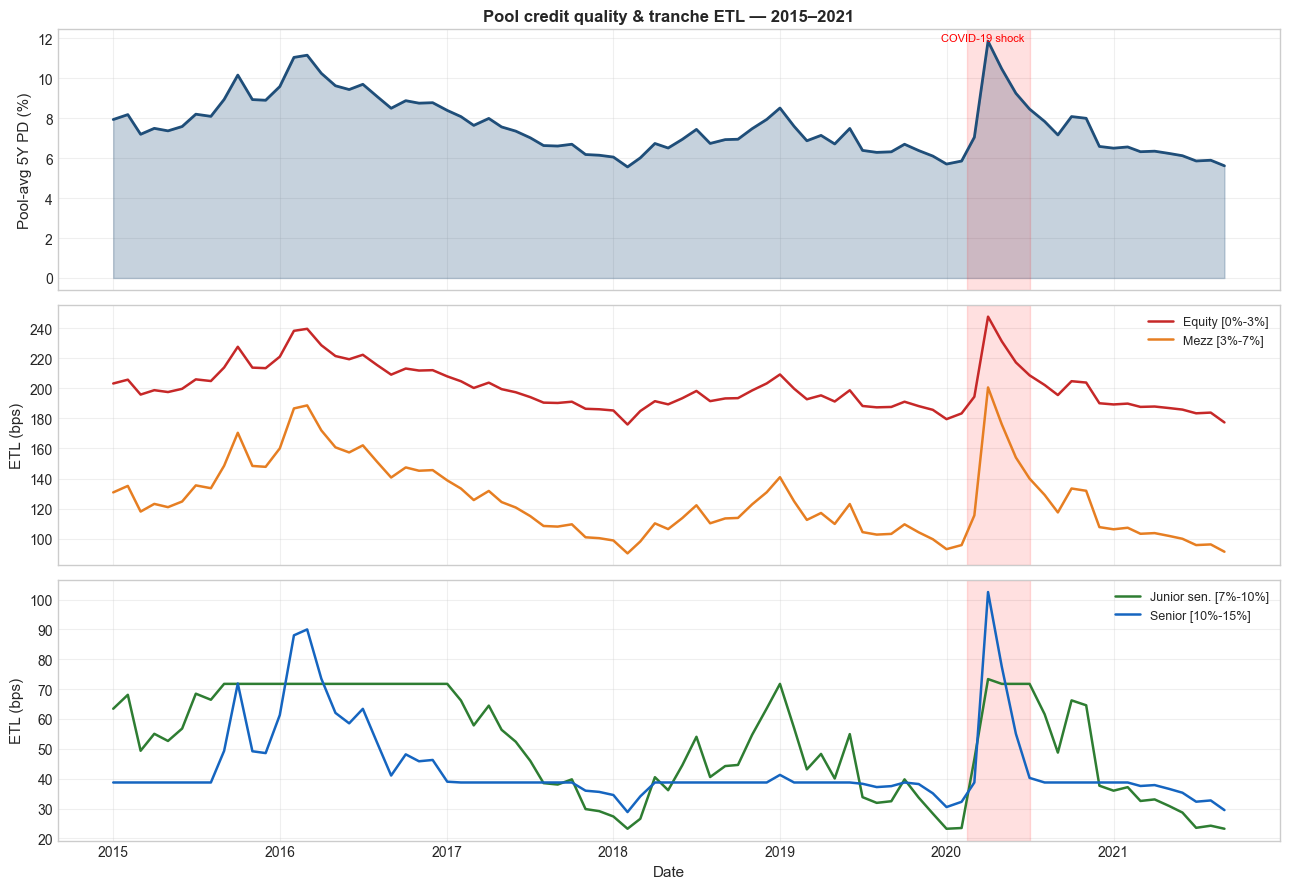


COVID leverage (peak ETL ÷ pre-COVID mean ETL)
  Equity        : 1.23×
  Mezz          : 1.57×
  Junior sen.   : 1.36×
  Senior        : 2.34×


In [26]:
# ── §7.1b Plot historical spreads with COVID shock ───────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
COVID_START = pd.Timestamp("2020-02-15")
COVID_END   = pd.Timestamp("2020-07-01")

# Panel 1 — pool PD
ax = axes[0]
ax.fill_between(hist_df.index, hist_df["p_avg"]*100, color=ACCENT, alpha=0.25)
ax.plot(hist_df.index, hist_df["p_avg"]*100, color=ACCENT, lw=2)
ax.axvspan(COVID_START, COVID_END, alpha=0.12, color="red")
ax.set_ylabel("Pool-avg 5Y PD (%)")
ax.set_title("Pool credit quality & tranche ETL — 2015–2021", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.annotate("COVID-19 shock", xy=(pd.Timestamp("2020-03-20"), hist_df['p_avg'].max()*100),
            fontsize=8, color="red", ha="center")

# Panel 2 — equity + mezz
ax = axes[1]
for name, a, d in TRANCHES[:2]:
    ax.plot(hist_df.index, hist_df[name], color=TRANCHE_COLORS[name], lw=1.8,
            label=f"{name} [{a:.0%}-{d:.0%}]")
ax.axvspan(COVID_START, COVID_END, alpha=0.12, color="red")
ax.set_ylabel("ETL (bps)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3 — jr senior + senior
ax = axes[2]
for name, a, d in TRANCHES[2:]:
    ax.plot(hist_df.index, hist_df[name], color=TRANCHE_COLORS[name], lw=1.8,
            label=f"{name} [{a:.0%}-{d:.0%}]")
ax.axvspan(COVID_START, COVID_END, alpha=0.12, color="red")
ax.set_ylabel("ETL (bps)"); ax.set_xlabel("Date")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

pre  = hist_df[hist_df.index < "2020-01-01"]
peak = hist_df[(hist_df.index >= "2020-02-01") & (hist_df.index <= "2020-06-01")]
print("\nCOVID leverage (peak ETL ÷ pre-COVID mean ETL)")
for name, *_ in TRANCHES:
    ratio = peak[name].max() / pre[name].mean() if pre[name].mean() > 0 else float("nan")
    print(f"  {name:<14}: {ratio:.2f}×")


### §7.2 Final risk report & validation checklist

Risk report bao gồm: pricing summary, Greeks, BC curve, và 4 validation checks must-pass theo quy trình model validation chuẩn (repricing, LHP-MC consistency, capital structure monotonicity, correlation-sign reasoning).


In [27]:
# ── §7.2 Final risk report ──────────────────────────────────
hr = "=" * 94
print(hr)
print("                  SYNTHETIC CDO  —  FINAL RISK REPORT")
print(hr)
print(f"Valuation date     : {valuation_date.date()}")
print(f"Reference pool     : N = {N} names, equal-weight, T = {T_MAT:.0f}Y")
print(f"Model              : 1-factor Gaussian copula, ρ = {rho_price}")
print(f"Curves             : ISDA piecewise-constant bootstrap ({len(BOOT_TENORS)} tenors)")
print(f"Risk-free / Recov. : r = {risk_free_rate:.1%}   |   R = {R:.0%}")
print(hr)
tname = [n for n, *_ in TRANCHES]
print(f"{'Metric':<32} " + " ".join(f"{n:>14}" for n in tname))
print("-"*94)
for label, vals in [
    ("Attach / Detach",              [f"{a:.0%}–{d:.0%}" for _,a,d in TRANCHES]),
    ("ETL@5Y  (MC, of notional)",    [f"{mc_etl_dict[n]:.5f}"   for n in tname]),
    ("ETL@5Y  (LHP)",                [f"{lhp_etl_dict[n]:.5f}"  for n in tname]),
    ("Fair spread (bps)",            [f"{s_base_g[n]*1e4:.1f}"  for n in tname]),
    ("CS01    (bps / +1bp)",         [f"{cs01[n]:+.3f}"         for n in tname]),
    ("Rho01   (bps / +1% ρ)",        [f"{rho01[n]:+.3f}"        for n in tname]),
    ("DV01    (bps / +1bp rate)",    [f"{dv01[n]:+.3f}"         for n in tname]),
    ("JtD     (bps / 1 default)",    [f"{jtd[n]:+.2f}"          for n in tname]),
]:
    print(f"{label:<32} " + " ".join(f"{v:>14}" for v in vals))
print(hr)
print("Base-correlation curve (recovered from stylised market quotes)")
for d, rho_bc in zip(detach_pts, rho_pts):
    print(f"  [0-{d:.0%}]  BC = {rho_bc*100:.2f}%")
print(hr)

# Validation checklist — computed live
repricing_pass   = (np.abs(errors_npv) < 1e-5).mean() >= 0.99
cap_struct_mono  = (s_base_g["Equity"] > s_base_g["Mezz"] >
                    s_base_g["Junior sen."] > s_base_g["Senior"])
rho_sign_equity  = rho01["Equity"]  < 0     # long-correlation: spread DOWN as rho UP
rho_sign_senior  = rho01["Senior"]  > 0     # short-correlation: spread UP as rho UP
equity_lhp_err   = abs(lhp_etl_dict["Equity"] - mc_etl_dict["Equity"]) \
                   / max(mc_etl_dict["Equity"], 1e-9)

def _tag(ok): return "[PASS]" if ok else "[FAIL]"

print("Validation checklist")
print(f"  {_tag(repricing_pass)}  ISDA bootstrap repricing error < 1e-5  "
      f"({(np.abs(errors_npv)<1e-5).mean()*100:.1f}% names)")
print(f"  {_tag(equity_lhp_err<0.20)}  LHP vs MC equity ETL relative error "
      f"= {equity_lhp_err*100:.1f}%  (target < 20%)")
print(f"  {_tag(cap_struct_mono)}  Capital-structure monotonicity: "
      f"Equity > Mezz > JrSen > Senior")
print(f"  {_tag(rho_sign_equity and rho_sign_senior)}  Correlation-sign check: "
      f"Equity long-rho (Rho01<0), Senior short-rho (Rho01>0)")
print(hr)
print("Notes")
print("  - For MEZZ / SENIOR tranches the LHP homogeneous approximation")
print("    is expected to deviate from heterogeneous-pool MC by 10-70%. Use")
print("    MC or bucketed LHP for production marks beyond equity.")
print("  - Base-correlation curve here is pedagogical round-trip from")
print("    stylised quotes. In production, feed actual iTraxx/CDX quotes.")
print(hr)


                  SYNTHETIC CDO  —  FINAL RISK REPORT
Valuation date     : 2021-09-10
Reference pool     : N = 651 names, equal-weight, T = 5Y
Model              : 1-factor Gaussian copula, ρ = 0.3
Curves             : ISDA piecewise-constant bootstrap (6 tenors)
Risk-free / Recov. : r = 2.0%   |   R = 40%
Metric                                   Equity           Mezz    Junior sen.         Senior
----------------------------------------------------------------------------------------------
Attach / Detach                           0%–3%          3%–7%         7%–10%        10%–15%
ETL@5Y  (MC, of notional)               0.01834        0.00909        0.00304        0.00222
ETL@5Y  (LHP)                           0.01716        0.00900        0.00322        0.00242
Fair spread (bps)                        1952.6          503.3          202.7           85.4
CS01    (bps / +1bp)                    +21.926         +9.641         +5.628         +3.019
Rho01   (bps / +1% ρ)                  